

The aim of this project is to design and implement a machine learning-based degree class predictive system for undergraduate students at Salem University, Lokoja, using historical and current student academic data, thereby enabling early identification of at-risk students and supporting proactive academic interventions by university advisors and administrators.

I made use of the OULAD (Open University Learning Analytics Dataset) for this project, which provides a rich set of data on student demographics, academic performance, and engagement metrics. The dataset includes the following key components:

OULAD - Preprocessing & EDA Pipeline
Degree Class Prediction System
============================================================
#### Dataset used:

  - studentInfo.csv — the core table: demographics, entry qualifications, and crucially the final_result (the target variable)

| Feature                | Description                                                                                                                                    | Relevance to the Project                                                                                                                        |
| ---------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------ |
| `code_module`          | Module code (AAA, BBB, CCC, etc.)                                                                                                              | Identifies which course the student took                                                                                                         |
| `code_presentation`    | Presentation code (e.g., 2013J, 2014B)                                                                                                         | J = October start, B = February start; different cohorts may have different structures                                                           |
| `id_student`           | Unique student identifier                                                                                                                      | Primary key for joining all tables                                                                                                               |
| `gender`               | M/F                                                                                                                                            | Demographic indicator — may correlate with engagement patterns or outcomes                                                                       |
| `region`               | Geographic region (e.g., Scotland, Wales, East Anglian Region)                                                                                 | Socio-geographic proxy; some regions have higher deprivation                                                                                     |
| `highest_education`    | Entry qualification level (HE Qualification, A Level or Equivalent, Lower Than A Level, Post Graduate Qualification, No Formal Qualifications) | **Entry qualification** — strong predictor of academic readiness                                                                                 |
| `imd_band`             | Index of Multiple Deprivation band (0-10%, 10-20%, ..., 90-100%)                                                                               | **Socioeconomic status proxy** — students from lower IMD bands often face more barriers                                                          |
| `age_band`             | Age group (0-35, 35-55, 55<=)                                                                                                                  | Mature students may have different engagement patterns                                                                                           |
| `num_of_prev_attempts` | How many times the student has attempted this module before                                                                                    | **Risk indicator** — repeated attempts suggest struggle                                                                                          |
| `studied_credits`      | Total credits the student is currently studying across all modules                                                                             | Workload indicator — high credit load may correlate with withdrawal                                                                              |
| `disability`           | Y/N                                                                                                                                            | Students with declared disabilities may need additional support                                                                                  |
| `final_result`         | **Target variable**: Distinction, Pass, Fail, Withdrawn                                                                                        | The outcome we're predicting. Note: OULAD uses module-level results, not degree class. We'll need to aggregate or map these to degree classes. |

<br/>
<br/>

  - studentAssessment.csv — individual assessment scores → builds TMA performance, score progression, weighted averages

| Feature          | Description                                                               | Relevance to the Project                                                    |
| ---------------- | ------------------------------------------------------------------------- | ---------------------------------------------------------------------------- |
| `id_assessment`  | Links to `assessments.csv`                                                | Needed to know assessment type, weight, and due date                         |
| `id_student`     | Student identifier                                                        | Join key to `studentInfo`                                                    |
| `date_submitted` | Days since module start when the assessment was submitted                 | **Temporal feature** — early vs. late submission patterns predict engagement |
| `is_banked`      | 0/1 flag — whether the score was transferred from a previous presentation | Banked scores may not reflect current performance; handle carefully          |
| `score`          | Student's score (0–100)                                                   | **Core academic performance metric** — scores < 40 = Fail                    |


<br/>
<br/>

  - assessments.csv — the lookup table for assessment types, weights, and dates (needed to make studentAssessment meaningful)

| Feature             | Description                                        | Relevance to the Project                                                             |
| ------------------- | -------------------------------------------------- | ------------------------------------------------------------------------------------- |
| `code_module`       | Module code                                        | Join key                                                                              |
| `code_presentation` | Presentation code                                  | Join key                                                                              |
| `id_assessment`     | Unique assessment ID                               | Join key to `studentAssessment`                                                       |
| `assessment_type`   | TMA (Tutor Marked), CMA (Computer Marked), or Exam | Different types have different pedagogical weight and student behavior                |
| `date`              | Due date (days since module start)                 | For calculating submission timeliness; "?" means exam at end of module                |
| `weight`            | Percentage weight toward final grade               | **Critical for weighted averages** — Exams are typically 100%, while TMAs sum to 100% |

<br/>
<br/>

  - studentVle.csv — click/engagement data → attendance/engagement proxy (since there's no physical attendance data in OULAD)

| Feature             | Description                                                                   | Relevance to the Project                                 |
| ------------------- | ----------------------------------------------------------------------------- | --------------------------------------------------------- |
| `code_module`       | Module code                                                                   | Join key                                                  |
| `code_presentation` | Presentation code                                                             | Join key                                                  |
| `id_student`        | Student identifier                                                            | Join key                                                  |
| `id_site`           | VLE material identifier                                                       | Links to `vle.csv` for activity type                      |
| `date`              | Day of interaction (days since module start; negative = before module begins) | **Temporal feature** — engagement timing matters          |
| `sum_click`         | Number of clicks on that material that day                                    | **Engagement intensity** — proxy for study time/attention |



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid", font_scale=1.1)
plt.rcParams.update(
    {
        "figure.facecolor": "#0f1117",
        "axes.facecolor": "#1a1d27",
        "axes.edgecolor": "#3a3d4d",
        "axes.labelcolor": "#e0e0e0",
        "xtick.color": "#b0b0b0",
        "ytick.color": "#b0b0b0",
        "text.color": "#e0e0e0",
        "grid.color": "#2a2d3a",
        "grid.linestyle": "--",
        "grid.alpha": 0.4,
        "figure.dpi": 130,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
        "savefig.facecolor": "#0f1117",
    }
)

TARGET_ORDER = ["Distinction", "Pass", "Fail", "Withdrawn"]
TARGET_COLORS = {
    "Distinction": "#4e9af1",
    "Pass": "#4ef18a",
    "Fail": "#f14e4e",
    "Withdrawn": "#f1c94e",
}
PALETTE = [TARGET_COLORS[t] for t in TARGET_ORDER]

In [2]:
# Load datasets
student_info = pd.read_csv("studentInfo.csv")
student_assessment = pd.read_csv("studentAssessment.csv")
assessments = pd.read_csv("assessments.csv")
student_vle = pd.read_csv("studentVle.csv")

In [3]:
print(f"studentInfo : {student_info.shape}")
print(f"studentAssessment : {student_assessment.shape}")
print(f"assessments : {assessments.shape}")
print(f"studentVle: {student_vle.shape}")

studentInfo : (32593, 12)
studentAssessment : (173912, 5)
assessments : (206, 6)
studentVle: (10655280, 6)


In [4]:
# Quick peek at the data
for name, df in [
    ("studentInfo", student_info),
    ("studentAssessment", student_assessment),
    ("assessments", assessments),
    ("studentVle", student_vle),
]:
    print(f"\n── {name} ──────────────────────────")
    print(df.dtypes.to_string())
    print(f"\n  Null / '?' counts:")
    print(df.isin(["?"]).sum()[df.isin(["?"]).sum() > 0].to_string() or "  None")
    print(f"  Actual nulls: {df.isnull().sum().sum()}")


── studentInfo ──────────────────────────
code_module             object
code_presentation       object
id_student               int64
gender                  object
region                  object
highest_education       object
imd_band                object
age_band                object
num_of_prev_attempts     int64
studied_credits          int64
disability              object
final_result            object

  Null / '?' counts:
imd_band    1111
  Actual nulls: 0

── studentAssessment ──────────────────────────
id_assessment      int64
id_student         int64
date_submitted     int64
is_banked          int64
score             object

  Null / '?' counts:
score    173
  Actual nulls: 0

── assessments ──────────────────────────
code_module           object
code_presentation     object
id_assessment          int64
assessment_type       object
date                  object
weight               float64

  Null / '?' counts:
date    11
  Actual nulls: 0

── studentVle ──────────────────

## StudentInfo Dataset

In [5]:
si = student_info.copy()

# Replace '?' sentinel with NaN
si.replace("?", np.nan, inplace=True)

# Target variable
# Keep all 4 classes; map to ordinal for later use
target_map = {"Withdrawn": 0, "Fail": 1, "Pass": 2, "Distinction": 3}
si["target"] = si["final_result"]
si["target_encoded"] = si["final_result"].map(target_map)

In [6]:
# IMD Band → numeric deprivation score (midpoint of band)
imd_midpoint = {
    "0-10%": 5,
    "10-20%": 15,
    "20-30%": 25,
    "30-40%": 35,
    "40-50%": 45,
    "50-60%": 55,
    "60-70%": 65,
    "70-80%": 75,
    "80-90%": 85,
    "90-100%": 95,
}
si["imd_band_numeric"] = si["imd_band"].map(imd_midpoint)
si["imd_band_numeric"].fillna(si["imd_band_numeric"].median(), inplace=True)

In [7]:
#  Education leve (ordinal)
edu_order = {
    "No Formal quals": 0,
    "Lower Than A Level": 1,
    "A Level or Equivalent": 2,
    "HE Qualification": 3,
    "Post Graduate Qualification": 4,
}
si["edu_level_num"] = si["highest_education"].map(edu_order)
si["edu_level_num"].fillna(si["edu_level_num"].median(), inplace=True)

In [8]:
# Age band (ordinal)
age_order = {"0-35": 0, "35-55": 1, "55<=": 2}
si["age_band_num"] = si["age_band"].map(age_order)

In [9]:
# Binary flags
si["is_female"] = (si["gender"] == "F").astype(int)
si["has_disability"] = (si["disability"] == "Y").astype(int)

In [10]:
# Repeat attempter flag
si["is_repeat_student"] = (si["num_of_prev_attempts"] > 0).astype(int)

print(f"  studentInfo cleaned : {si.shape}")
print(
    f"  Missing after clean : {si[['imd_band_numeric','edu_level_num','age_band_num']].isnull().sum().sum()}"
)
print(f"\n  Target distribution:\n{si['target'].value_counts()}")

  studentInfo cleaned : (32593, 20)
  Missing after clean : 0

  Target distribution:
target
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64


In [12]:
si.sample(10)

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,target,target_encoded,imd_band_numeric,edu_level_num,age_band_num,is_female,has_disability,is_repeat_student
25409,FFF,2013J,592689,M,East Anglian Region,HE Qualification,80-90%,0-35,0,60,N,Pass,Pass,2,85.0,3,0,0,0,0
12463,CCC,2014J,675823,M,North Region,HE Qualification,NaN,35-55,0,30,N,Withdrawn,Withdrawn,0,55.0,3,1,0,0,0
28869,FFF,2014J,648698,M,South Region,A Level or Equivalent,80-90%,0-35,0,60,N,Withdrawn,Withdrawn,0,85.0,2,0,0,0,0
32377,GGG,2014J,682100,M,Wales,A Level or Equivalent,10-20,35-55,0,30,N,Pass,Pass,2,55.0,2,1,0,0,0
30977,GGG,2013J,2386281,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,Y,Pass,Pass,2,95.0,1,1,1,1,0
27226,FFF,2014B,626778,M,Scotland,Lower Than A Level,70-80%,35-55,0,90,N,Pass,Pass,2,75.0,1,1,0,0,0
6935,BBB,2014J,585963,F,East Midlands Region,A Level or Equivalent,10-20,0-35,1,60,Y,Withdrawn,Withdrawn,0,55.0,2,0,1,1,1
17734,DDD,2014J,348602,F,South Region,Post Graduate Qualification,90-100%,35-55,0,120,N,Withdrawn,Withdrawn,0,95.0,4,1,1,0,0
8588,BBB,2014J,2426442,F,North Region,A Level or Equivalent,10-20,35-55,0,60,N,Withdrawn,Withdrawn,0,55.0,2,1,1,0,0
26347,FFF,2014B,337940,M,Scotland,Lower Than A Level,40-50%,0-35,0,60,N,Withdrawn,Withdrawn,0,45.0,1,0,0,0,0


## Assessments Dataset

In [13]:
asm = assessments.copy()
asm.replace("?", np.nan, inplace=True)
asm["date"] = pd.to_numeric(asm["date"], errors="coerce")
asm["weight"] = pd.to_numeric(asm["weight"], errors="coerce")

print(f"\n  Assessments cleaned : {asm.shape}")
print(f"  Assessment types    : {asm['assessment_type'].unique()}")
print(f"  Exam rows (date=NaN): {asm['date'].isna().sum()}")


  Assessments cleaned : (206, 6)
  Assessment types    : ['TMA' 'Exam' 'CMA']
  Exam rows (date=NaN): 11


## studentAssessment Dataset

In [14]:
sa = student_assessment.copy()
sa["score"] = pd.to_numeric(sa["score"], errors="coerce")

# Merge in assessment metadata
sa = sa.merge(
    asm[
        [
            "id_assessment",
            "code_module",
            "code_presentation",
            "assessment_type",
            "date",
            "weight",
        ]
    ],
    on="id_assessment",
    how="left",
)

# Submission timeliness: positive = submitted early, negative = late
sa["days_early"] = sa["date"] - sa["date_submitted"]

print(f"\n  studentAssessment merged: {sa.shape}")
print(
    f"  Score nulls: {sa['score'].isna().sum()} "
    f"({sa['score'].isna().mean()*100:.1f}%)"
)
print(
    f"  Score range: [{sa['score'].min():.1f}, {sa['score'].max():.1f}]"
)


  studentAssessment merged: (173912, 11)
  Score nulls: 173 (0.1%)
  Score range: [0.0, 100.0]


## studentVle Dataset

In [15]:
sv = student_vle.copy()
sv["sum_click"] = pd.to_numeric(sv["sum_click"], errors="coerce").fillna(0)

# Remove impossible negative click counts
sv = sv[sv["sum_click"] >= 0]

print(f"\nstudentVle cleaned : {sv.shape}")
print(f"Total clicks : {sv['sum_click'].sum():,.0f}")
print(f"Date range : [{sv['date'].min()}, {sv['date'].max()}]")


studentVle cleaned : (10655280, 6)
Total clicks : 39,605,099
Date range : [-25, 269]


## Feature Engineering

In [16]:
KEY = ["code_module", "code_presentation", "id_student"]

tma = sa[sa["assessment_type"] == "TMA"].copy()
exam = sa[sa["assessment_type"] == "Exam"].copy()

# Basic descriptive stats per student
tma_stats = (
    tma.groupby(KEY)["score"]
    .agg(
        tma_mean="mean",
        tma_std="std",
        tma_min="min",
        tma_max="max",
        tma_count="count",
    )
    .reset_index()
)
tma_stats["tma_std"].fillna(0, inplace=True)  # students with 1 TMA get 0 std




In [17]:
# Weighted average (weighted by assessment weight)
def weighted_avg(grp):
    w = grp["weight"].fillna(1)
    s = grp["score"].fillna(0)
    return (s * w).sum() / w.sum() if w.sum() > 0 else np.nan


tma_weighted = tma.groupby(KEY).apply(weighted_avg).reset_index(name="tma_weighted_avg")

In [18]:
# Score trend over the module (linear slope of TMA scores in chronological order)
# Positive slope → improving; negative → declining
def score_trend(grp):
    grp = grp.dropna(subset=["score", "date"]).sort_values("date")
    if len(grp) < 2:
        return 0.0
    x = np.arange(len(grp))
    slope, *_ = np.polyfit(x, grp["score"], 1)
    return round(slope, 4)


tma_trend = tma.groupby(KEY).apply(score_trend).reset_index(name="tma_score_trend")

In [19]:
# Submission behaviour
tma_submit = (
    tma.groupby(KEY)["days_early"]
    .agg(
        avg_days_early="mean",
        late_submission_rate=lambda x: (x < 0).mean(),
    )
    .reset_index()
)

In [20]:
# Exam score
exam_stats = exam.groupby(KEY)["score"].mean().reset_index(name="exam_score")

print(f"TMA stats rows : {tma_stats.shape[0]}")
print(f"Exam stats rows: {exam_stats.shape[0]}")

TMA stats rows : 24820
Exam stats rows: 4959


## Let's create a CGPA Proxy using do main knowledge of how final degree classifications are typically computed in UK universities.

In [21]:
# A weighted combination of TMA performance and exam score,
# mimicking how final degree marks are typically computed.
# Weight: 60% coursework (TMA) + 40% exam
# ──────────────────────────────────────────────────────────────
cgpa_base = tma_weighted.merge(exam_stats, on=KEY, how="left")
cgpa_base["exam_score"].fillna(cgpa_base["tma_weighted_avg"], inplace=True)  # if no exam data
cgpa_base["cgpa_proxy"] = (
    cgpa_base["tma_weighted_avg"] * 0.60 +
    cgpa_base["exam_score"]        * 0.40
).round(2)
 
# Map CGPA proxy to conventional degree class bands
def cgpa_to_class(score):
    if   score >= 70: return "Distinction"
    elif score >= 60: return "Pass"
    elif score >= 40: return "Fail"
    else:             return "Withdrawn/Fail"
 
cgpa_base["predicted_class_from_cgpa"] = cgpa_base["cgpa_proxy"].apply(cgpa_to_class)

## VLE Engagement Features

In [22]:
# Overall engagement
vle_overall = (
    sv.groupby(KEY)
    .agg(
        total_clicks=("sum_click", "sum"),
        total_sessions=("sum_click", "count"),
        avg_clicks_per_session=("sum_click", "mean"),
        active_days=("date", lambda x: x.nunique()),
    )
    .reset_index()
)

In [23]:
# Engagement by phase of module
# Early  : days -10 to 75   (first ~30% of module)
# Mid    : days 76  to 150  (middle ~30%)
# Late   : days 151+         (final ~40%)
sv["phase"] = pd.cut(
    sv["date"], bins=[-999, 75, 150, 9999], labels=["early", "mid", "late"]
)
phase_clicks = (
    sv.groupby(KEY + ["phase"])["sum_click"].sum().unstack(fill_value=0).reset_index()
)
phase_clicks.columns = KEY + [f"clicks_{p}" for p in ["early", "mid", "late"]]

In [24]:
# Engagement consistency: coefficient of variation of weekly clicks
def click_cv(grp):
    weekly = grp.groupby("date")["sum_click"].sum()
    if weekly.std() == 0 or weekly.mean() == 0:
        return 0.0
    return weekly.std() / weekly.mean()


vle_cv = sv.groupby(KEY).apply(click_cv).reset_index(name="click_cv")

print(f"  VLE overall rows   : {vle_overall.shape[0]}")
print(f"  Phase clicks rows  : {phase_clicks.shape[0]}")

  VLE overall rows   : 29228
  Phase clicks rows  : 730072


## Merge All Features

In [25]:
# Start from demographic base
demo_cols = KEY + [
    "gender",
    "region",
    "highest_education",
    "imd_band",
    "imd_band_numeric",
    "edu_level_num",
    "age_band",
    "age_band_num",
    "is_female",
    "has_disability",
    "num_of_prev_attempts",
    "is_repeat_student",
    "studied_credits",
    "disability",
    "target",
    "target_encoded",
]
feat_df = si[demo_cols].copy()

# Assessment features
for df_right in [
    tma_stats,
    tma_weighted,
    tma_trend,
    tma_submit,
    exam_stats,
    cgpa_base[KEY + ["cgpa_proxy", "predicted_class_from_cgpa"]],
]:
    feat_df = feat_df.merge(df_right, on=KEY, how="left")

# VLE features
for df_right in [vle_overall, phase_clicks, vle_cv]:
    feat_df = feat_df.merge(df_right, on=KEY, how="left")

# Fill engagement zeros for students with no VLE data
vle_fill_cols = [
    "total_clicks",
    "total_sessions",
    "avg_clicks_per_session",
    "active_days",
    "clicks_early",
    "clicks_mid",
    "clicks_late",
    "click_cv",
]
for c in vle_fill_cols:
    if c in feat_df.columns:
        feat_df[c].fillna(0, inplace=True)

# Fill assessment zeros for withdrawn students (no submissions)
assess_fill_cols = [
    "tma_mean",
    "tma_std",
    "tma_min",
    "tma_max",
    "tma_weighted_avg",
    "tma_count",
    "tma_score_trend",
    "avg_days_early",
    "late_submission_rate",
    "exam_score",
    "cgpa_proxy",
]
for c in assess_fill_cols:
    if c in feat_df.columns:
        feat_df[c].fillna(0, inplace=True)

print(f"\n  Merged feature matrix: {feat_df.shape}")
print(f"  Remaining nulls      : {feat_df.isnull().sum().sum()}")
print(
    f"\n  Feature summary:\n{feat_df.describe().T[['mean','std','min','max']].round(2)}"
)


  Merged feature matrix: (32593, 39)
  Remaining nulls      : 8884

  Feature summary:
                             mean        std     min         max
id_student              706687.67  549167.31  3733.0  2716795.00
imd_band_numeric            51.70      25.35     5.0       95.00
edu_level_num                1.74       0.75     0.0        4.00
age_band_num                 0.30       0.47     0.0        2.00
is_female                    0.45       0.50     0.0        1.00
has_disability               0.10       0.30     0.0        1.00
num_of_prev_attempts         0.16       0.48     0.0        6.00
is_repeat_student            0.13       0.33     0.0        1.00
studied_credits             79.76      41.07    30.0      655.00
target_encoded               1.25       1.00     0.0        3.00
tma_mean                    54.15      33.40     0.0      100.00
tma_std                      7.30       8.45     0.0       70.00
tma_min                     45.26      31.78     0.0      100.00
tm

## Exploratory Data Analysis

In [26]:
# helper function for label bars
def label_bars(ax, fmt="{:.0f}", pad=3):
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(
                fmt.format(h),
                (p.get_x() + p.get_width() / 2, h + pad),
                ha="center",
                va="bottom",
                fontsize=8,
                color="#e0e0e0",
            )

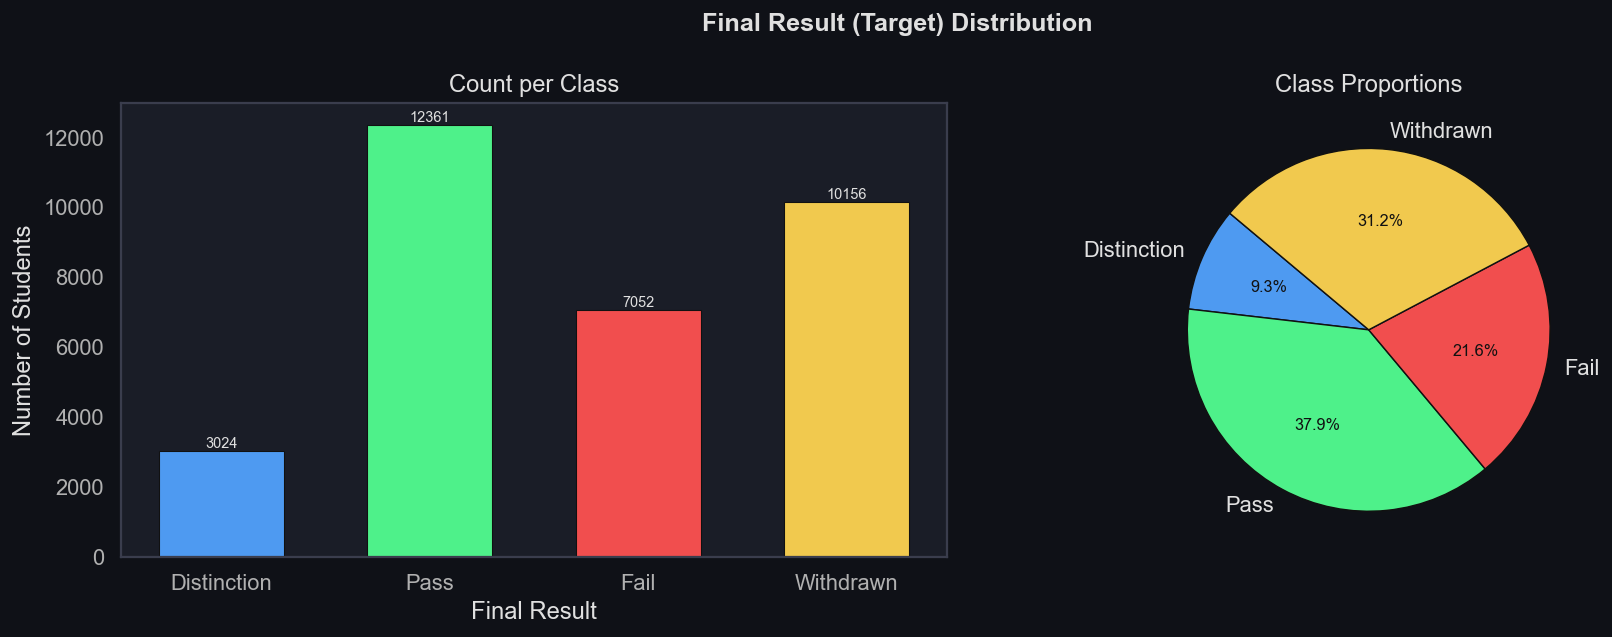

In [29]:
# Target class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Final Result (Target) Distribution", fontsize=14, fontweight="bold"
)

counts = feat_df["target"].value_counts().reindex(TARGET_ORDER).dropna()
colors = [TARGET_COLORS[c] for c in counts.index]

axes[0].bar(
    counts.index,
    counts.values,
    color=colors,
    edgecolor="#111",
    linewidth=0.6,
    width=0.6,
)
label_bars(axes[0])
axes[0].set_title("Count per Class")
axes[0].set_xlabel("Final Result")
axes[0].set_ylabel("Number of Students")
axes[0].grid(False)

wedges, texts, autotexts = axes[1].pie(
    counts.values,
    labels=counts.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "#111", "linewidth": 0.8},
    textprops={"color": "#e0e0e0"},
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_color("#111")
axes[1].set_title("Class Proportions")

plt.tight_layout()
plt.savefig("1. target_distribution.png")
plt.show()

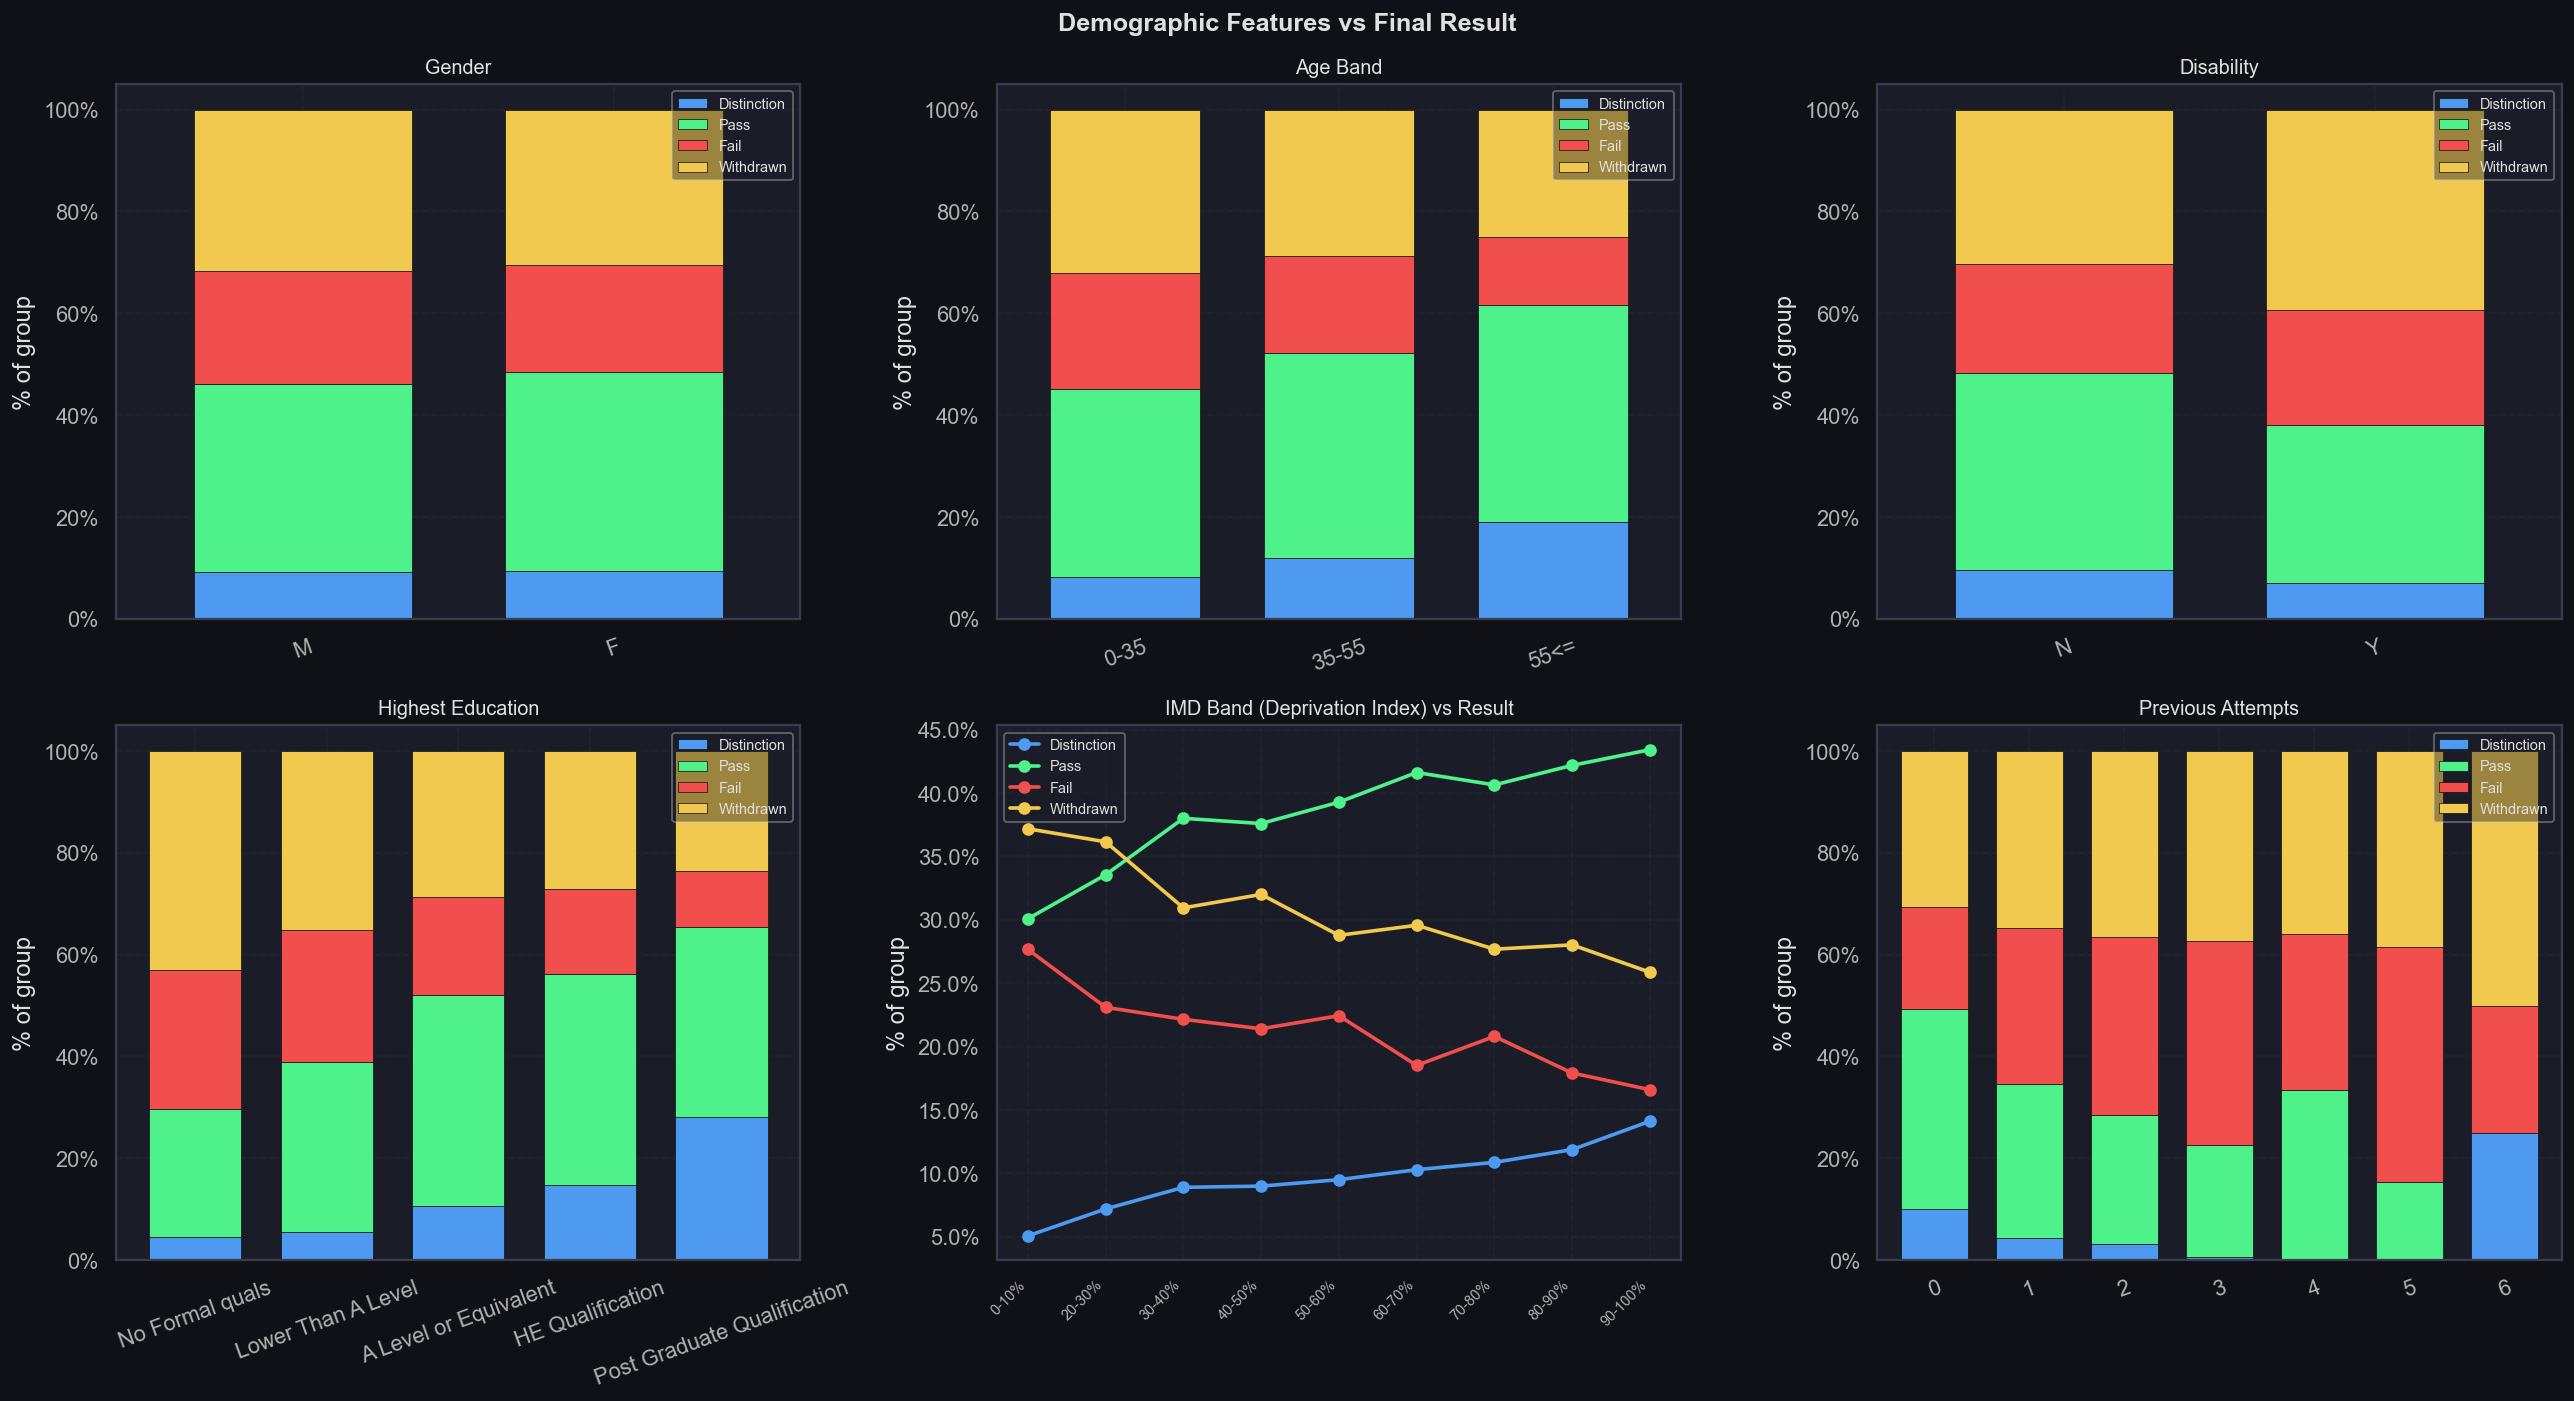

In [37]:
# Demographics vs Final Result
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle(
    "Demographic Features vs Final Result", fontsize=14, fontweight="bold"
)


def stacked_pct_bar(ax, col, title, order=None):
    """Stacked 100% bar chart of result breakdown per category."""
    ct = pd.crosstab(feat_df[col], feat_df["target"])
    ct = ct.reindex(columns=[c for c in TARGET_ORDER if c in ct.columns])
    if order:
        ct = ct.reindex([o for o in order if o in ct.index])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[TARGET_COLORS[c] for c in ct_pct.columns],
        edgecolor="#111",
        linewidth=0.4,
        width=0.7,
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("% of group")
    ax.tick_params(axis="x", rotation=20)
    ax.legend(loc="upper right", fontsize=8, framealpha=0.4)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())


stacked_pct_bar(axes[0, 0], "gender", "Gender", ["M", "F"])
stacked_pct_bar(axes[0, 1], "age_band", "Age Band", ["0-35", "35-55", "55<="])
stacked_pct_bar(axes[0, 2], "disability", "Disability", ["N", "Y"])
stacked_pct_bar(
    axes[0, 3] if axes.shape[1] > 3 else axes[1, 0],
    "highest_education",
    "Highest Education",
    [
        "No Formal quals",
        "Lower Than A Level",
        "A Level or Equivalent",
        "HE Qualification",
        "Post Graduate Qualification",
    ],
)

# IMD Band (deprivation) - line chart showing distinction & pass rate
imd_order = [
    "0-10%",
    "10-20%",
    "20-30%",
    "30-40%",
    "40-50%",
    "50-60%",
    "60-70%",
    "70-80%",
    "80-90%",
    "90-100%",
]
imd_avail = [b for b in imd_order if b in feat_df["imd_band"].values]
if imd_avail:
    ct2 = pd.crosstab(feat_df["imd_band"], feat_df["target"])
    ct2 = ct2.reindex(imd_avail).reindex(
        columns=[c for c in TARGET_ORDER if c in ct2.columns]
    )
    ct2_pct = ct2.div(ct2.sum(axis=1), axis=0) * 100
    ax_imd = axes[1, 1]
    for col in ct2_pct.columns:
        ax_imd.plot(
            range(len(ct2_pct)),
            ct2_pct[col],
            marker="o",
            label=col,
            color=TARGET_COLORS[col],
            lw=2,
        )
    ax_imd.set_xticks(range(len(imd_avail)))
    ax_imd.set_xticklabels(imd_avail, rotation=45, ha="right", fontsize=8)
    ax_imd.set_title("IMD Band (Deprivation Index) vs Result", fontsize=11)
    ax_imd.set_ylabel("% of group")
    ax_imd.legend(fontsize=8, framealpha=0.4)
    ax_imd.yaxis.set_major_formatter(mticker.PercentFormatter())

# Previous attempts
stacked_pct_bar(axes[1, 2], "num_of_prev_attempts", "Previous Attempts")

plt.tight_layout()
plt.savefig("2. demographics.png")
plt.show()

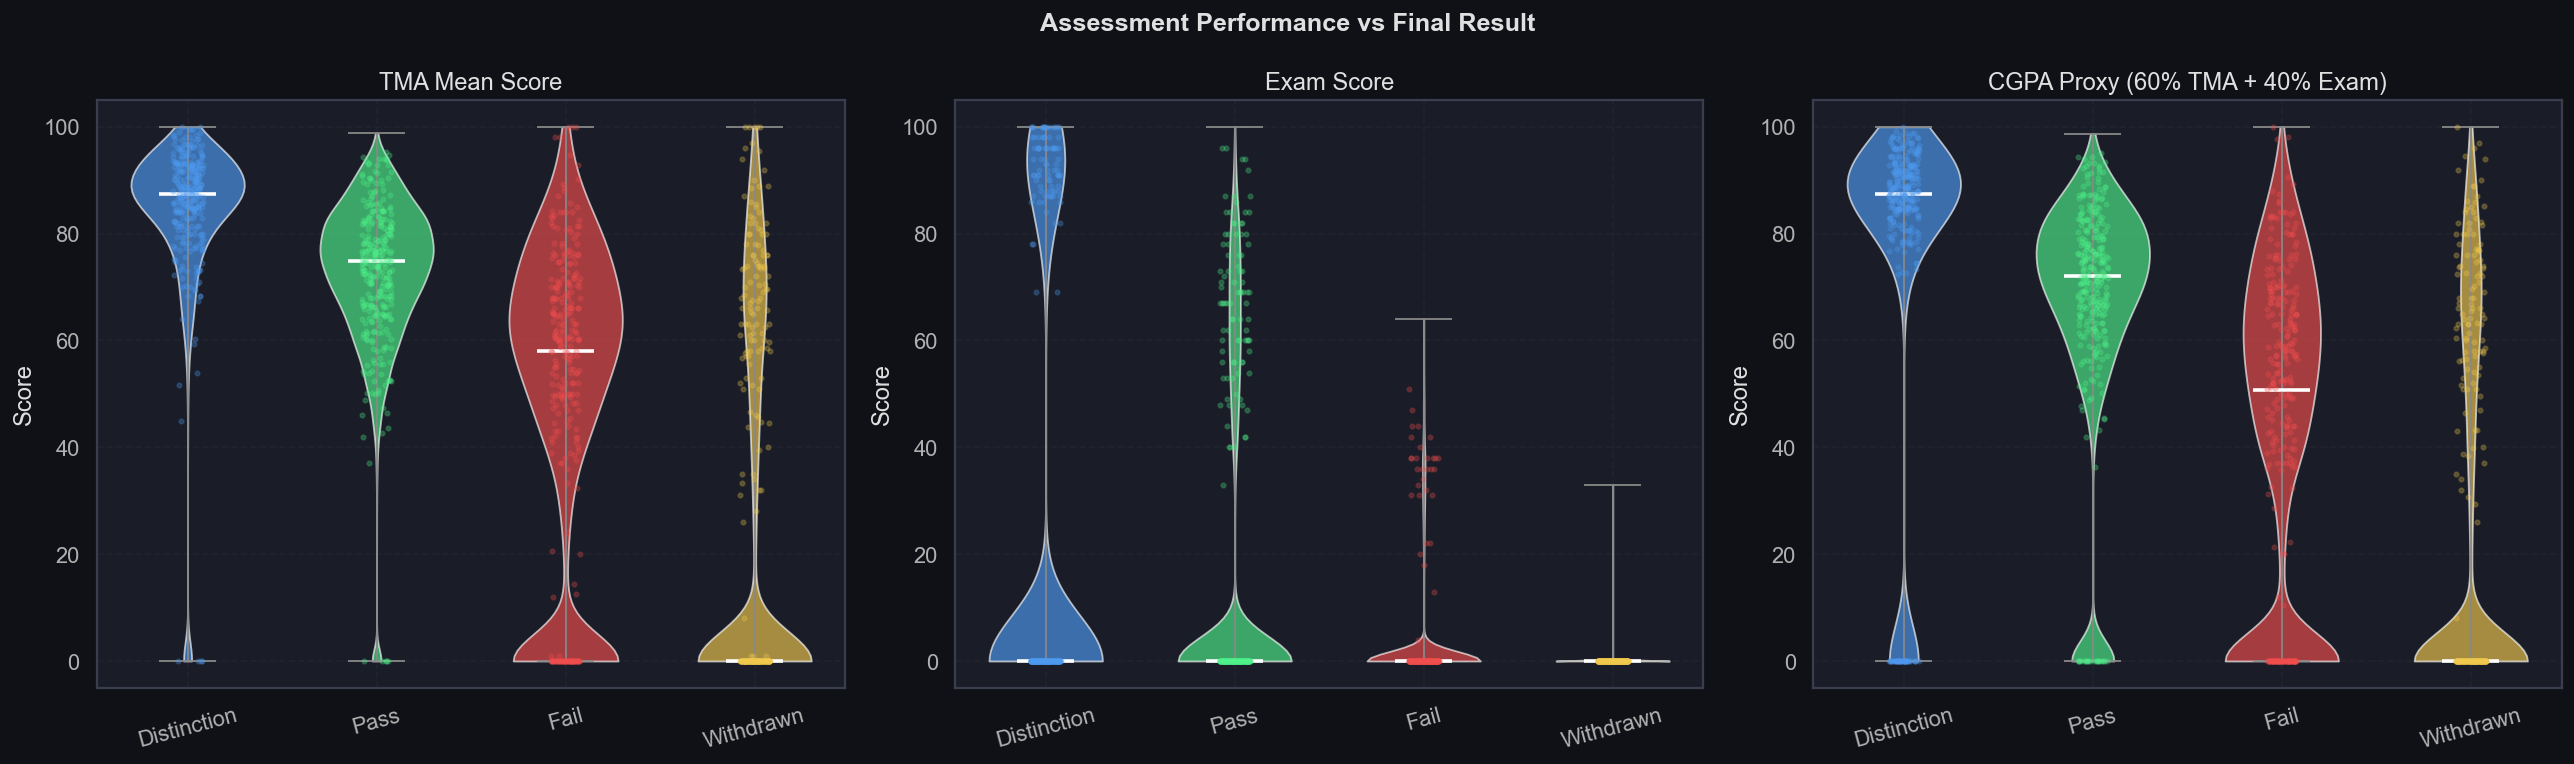

In [ ]:
# Assessment Performance
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    "Assessment Performance vs Final Result", fontsize=14, fontweight="bold"
)

for ax, col, title in zip(
    axes,
    ["tma_mean", "exam_score", "cgpa_proxy"],
    ["TMA Mean Score", "Exam Score", "CGPA Proxy (60% TMA + 40% Exam)"],
):

    data_groups = [feat_df[feat_df["target"] == t][col].dropna() for t in TARGET_ORDER]

    # Violin
    vp = ax.violinplot(
        data_groups,
        positions=range(len(TARGET_ORDER)),
        showmedians=True,
        showextrema=True,
        widths=0.6,
    )
    for pc, color in zip(vp["bodies"], PALETTE):
        pc.set_facecolor(color)
        pc.set_alpha(0.65)
    vp["cmedians"].set_color("white")
    vp["cmedians"].set_linewidth(2)
    for part in ["cbars", "cmaxes", "cmins"]:
        vp[part].set_color("#888")
        vp[part].set_linewidth(1)

    # Overlay strip plot
    for i, (grp, color) in enumerate(zip(data_groups, PALETTE)):
        jitter = np.random.uniform(-0.08, 0.08, size=min(len(grp), 300))
        sample = grp.sample(min(300, len(grp)), random_state=42)
        ax.scatter(
            i + jitter[: len(sample)], sample, alpha=0.25, s=6, color=color, zorder=3
        )

    ax.set_xticks(range(len(TARGET_ORDER)))
    ax.set_xticklabels(TARGET_ORDER, rotation=15)
    ax.set_title(title)
    ax.set_ylabel("Score")
    

plt.tight_layout()
plt.savefig("3. assessment_performance.png")
plt.show()

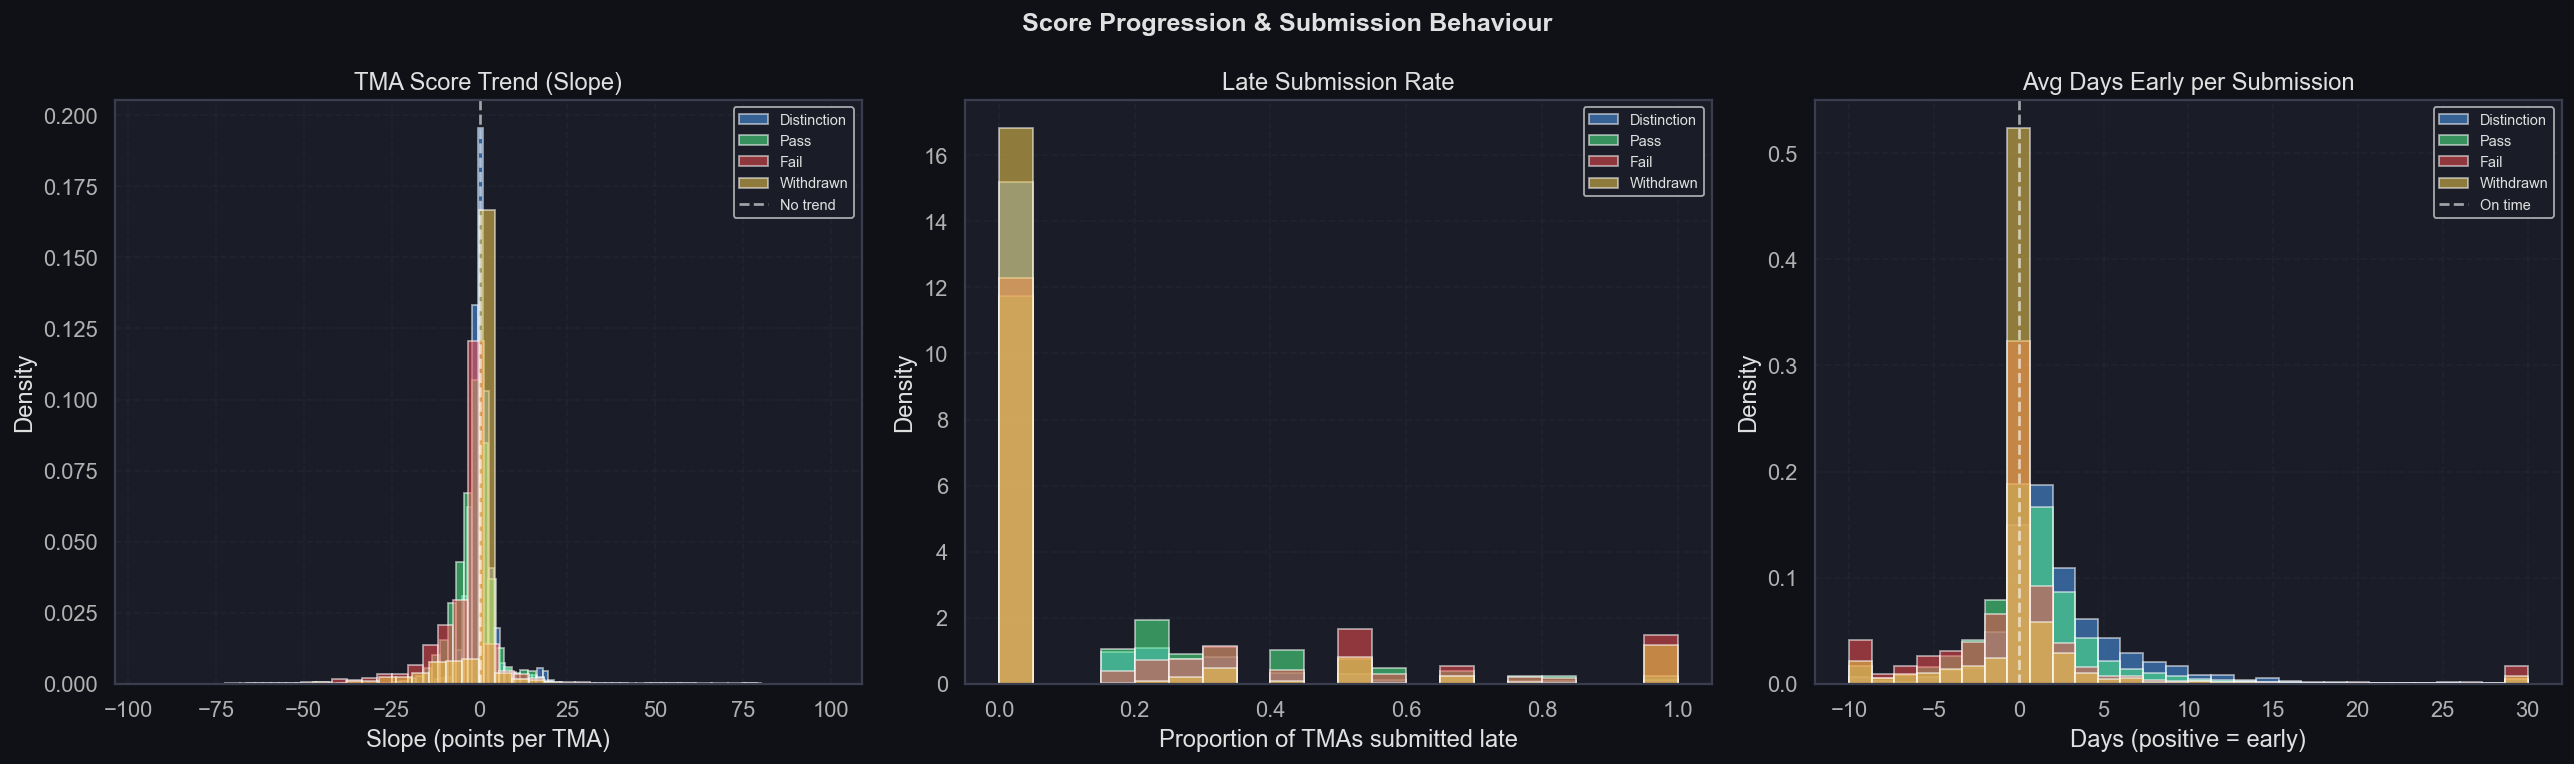

In [39]:
# TMA Score Trend & Submission Behaviour
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    "Score Progression & Submission Behaviour",
    fontsize=14,
    fontweight="bold",
)

# a: TMA score trend distribution
for t in TARGET_ORDER:
    vals = feat_df[feat_df["target"] == t]["tma_score_trend"].dropna()
    axes[0].hist(
        vals, bins=40, alpha=0.55, color=TARGET_COLORS[t], label=t, density=True
    )
axes[0].axvline(0, color="white", lw=1.5, ls="--", alpha=0.6, label="No trend")
axes[0].set_title("TMA Score Trend (Slope)")
axes[0].set_xlabel("Slope (points per TMA)")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=8)

# b: Late submission rate
for t in TARGET_ORDER:
    vals = feat_df[feat_df["target"] == t]["late_submission_rate"].dropna()
    axes[1].hist(
        vals, bins=20, alpha=0.55, color=TARGET_COLORS[t], label=t, density=True
    )
axes[1].set_title("Late Submission Rate")
axes[1].set_xlabel("Proportion of TMAs submitted late")
axes[1].set_ylabel("Density")
axes[1].legend(fontsize=8)

# c: Average days early/late
for t in TARGET_ORDER:
    vals = feat_df[feat_df["target"] == t]["avg_days_early"].dropna().clip(-10, 30)
    axes[2].hist(
        vals, bins=30, alpha=0.55, color=TARGET_COLORS[t], label=t, density=True
    )
axes[2].axvline(0, color="white", lw=1.5, ls="--", alpha=0.6, label="On time")
axes[2].set_title("Avg Days Early per Submission")
axes[2].set_xlabel("Days (positive = early)")
axes[2].set_ylabel("Density")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("4. score_progression.png")
plt.show()

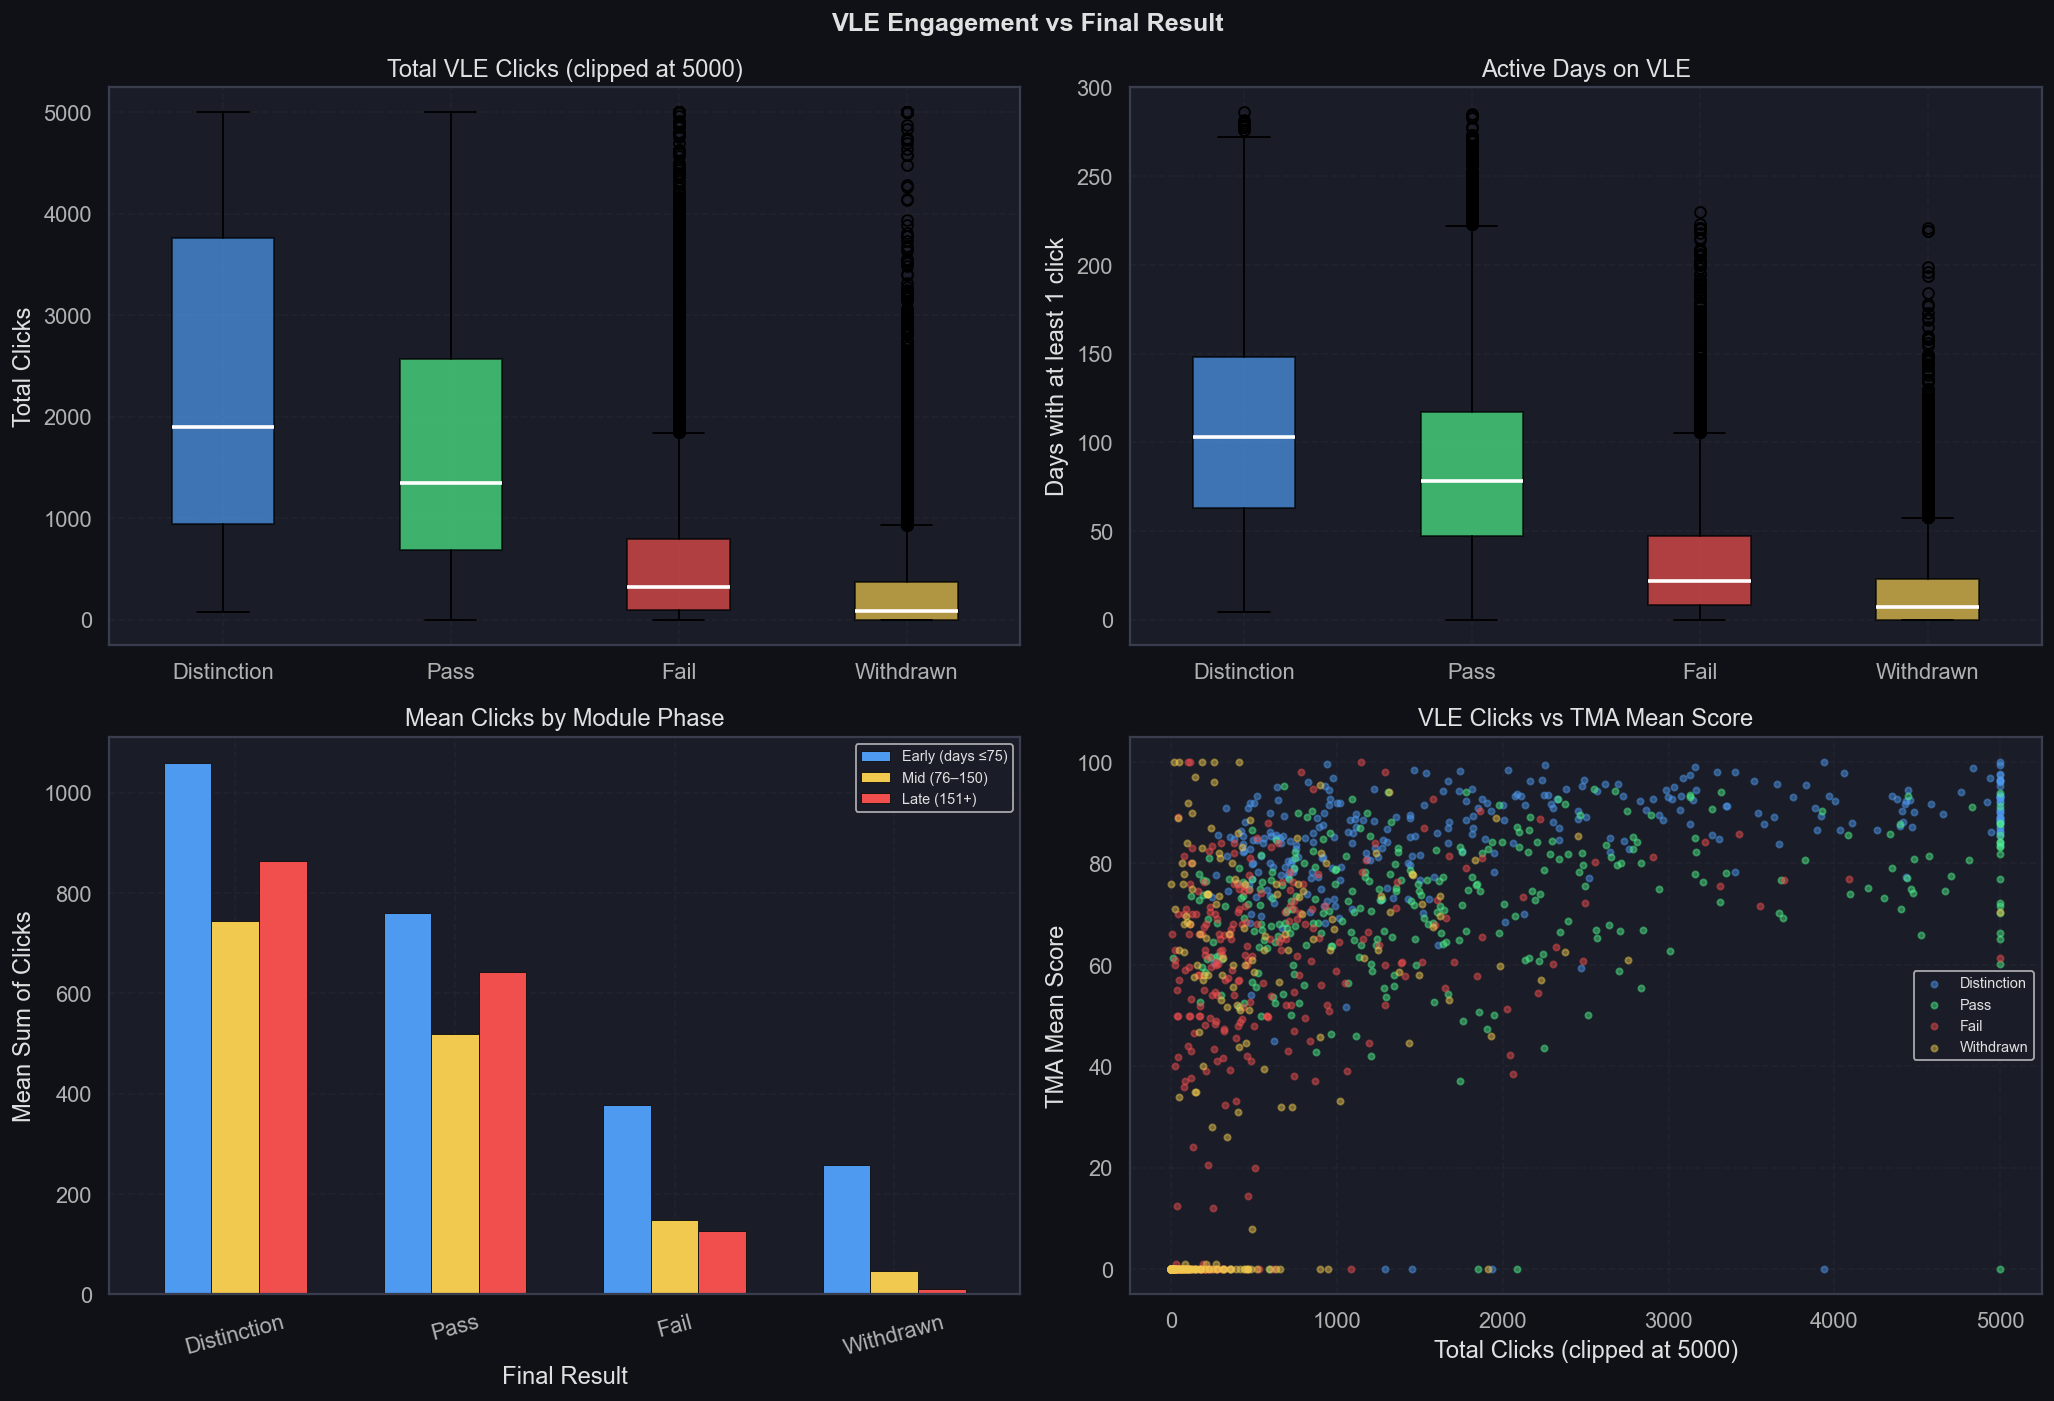

In [40]:
# VLE Engagement
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    "VLE Engagement vs Final Result", fontsize=14, fontweight="bold"
)

# a: Total clicks per class (box plot)
data_groups = [
    feat_df[feat_df["target"] == t]["total_clicks"].clip(upper=5000)
    for t in TARGET_ORDER
]
bp = axes[0, 0].boxplot(
    data_groups,
    patch_artist=True,
    labels=TARGET_ORDER,
    medianprops={"color": "white", "linewidth": 2},
)
for patch, color in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0, 0].set_title("Total VLE Clicks (clipped at 5000)")
axes[0, 0].set_ylabel("Total Clicks")

# b: Active days per class
data_groups_ad = [feat_df[feat_df["target"] == t]["active_days"] for t in TARGET_ORDER]
bp2 = axes[0, 1].boxplot(
    data_groups_ad,
    patch_artist=True,
    labels=TARGET_ORDER,
    medianprops={"color": "white", "linewidth": 2},
)
for patch, color in zip(bp2["boxes"], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0, 1].set_title("Active Days on VLE")
axes[0, 1].set_ylabel("Days with at least 1 click")

# c: Phase-based engagement (stacked bar showing mean clicks)
phase_mean = feat_df.groupby("target")[
    ["clicks_early", "clicks_mid", "clicks_late"]
].mean()
phase_mean = phase_mean.reindex(TARGET_ORDER).dropna()
phase_mean.plot(
    kind="bar",
    ax=axes[1, 0],
    color=["#4e9af1", "#f1c94e", "#f14e4e"],
    edgecolor="#111",
    linewidth=0.5,
    width=0.65,
)
axes[1, 0].set_title("Mean Clicks by Module Phase")
axes[1, 0].set_xlabel("Final Result")
axes[1, 0].set_ylabel("Mean Sum of Clicks")
axes[1, 0].tick_params(axis="x", rotation=15)
axes[1, 0].legend(["Early (days ≤75)", "Mid (76–150)", "Late (151+)"], fontsize=8)

# d: Click scatter - total_clicks vs tma_mean, coloured by class
for t in TARGET_ORDER:
    sub = feat_df[feat_df["target"] == t].sample(
        min(300, (feat_df["target"] == t).sum()), random_state=42
    )
    axes[1, 1].scatter(
        sub["total_clicks"].clip(upper=5000),
        sub["tma_mean"],
        alpha=0.45,
        s=12,
        color=TARGET_COLORS[t],
        label=t,
    )
axes[1, 1].set_title("VLE Clicks vs TMA Mean Score")
axes[1, 1].set_xlabel("Total Clicks (clipped at 5000)")
axes[1, 1].set_ylabel("TMA Mean Score")
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("5. vle_engagement.png")
plt.show()

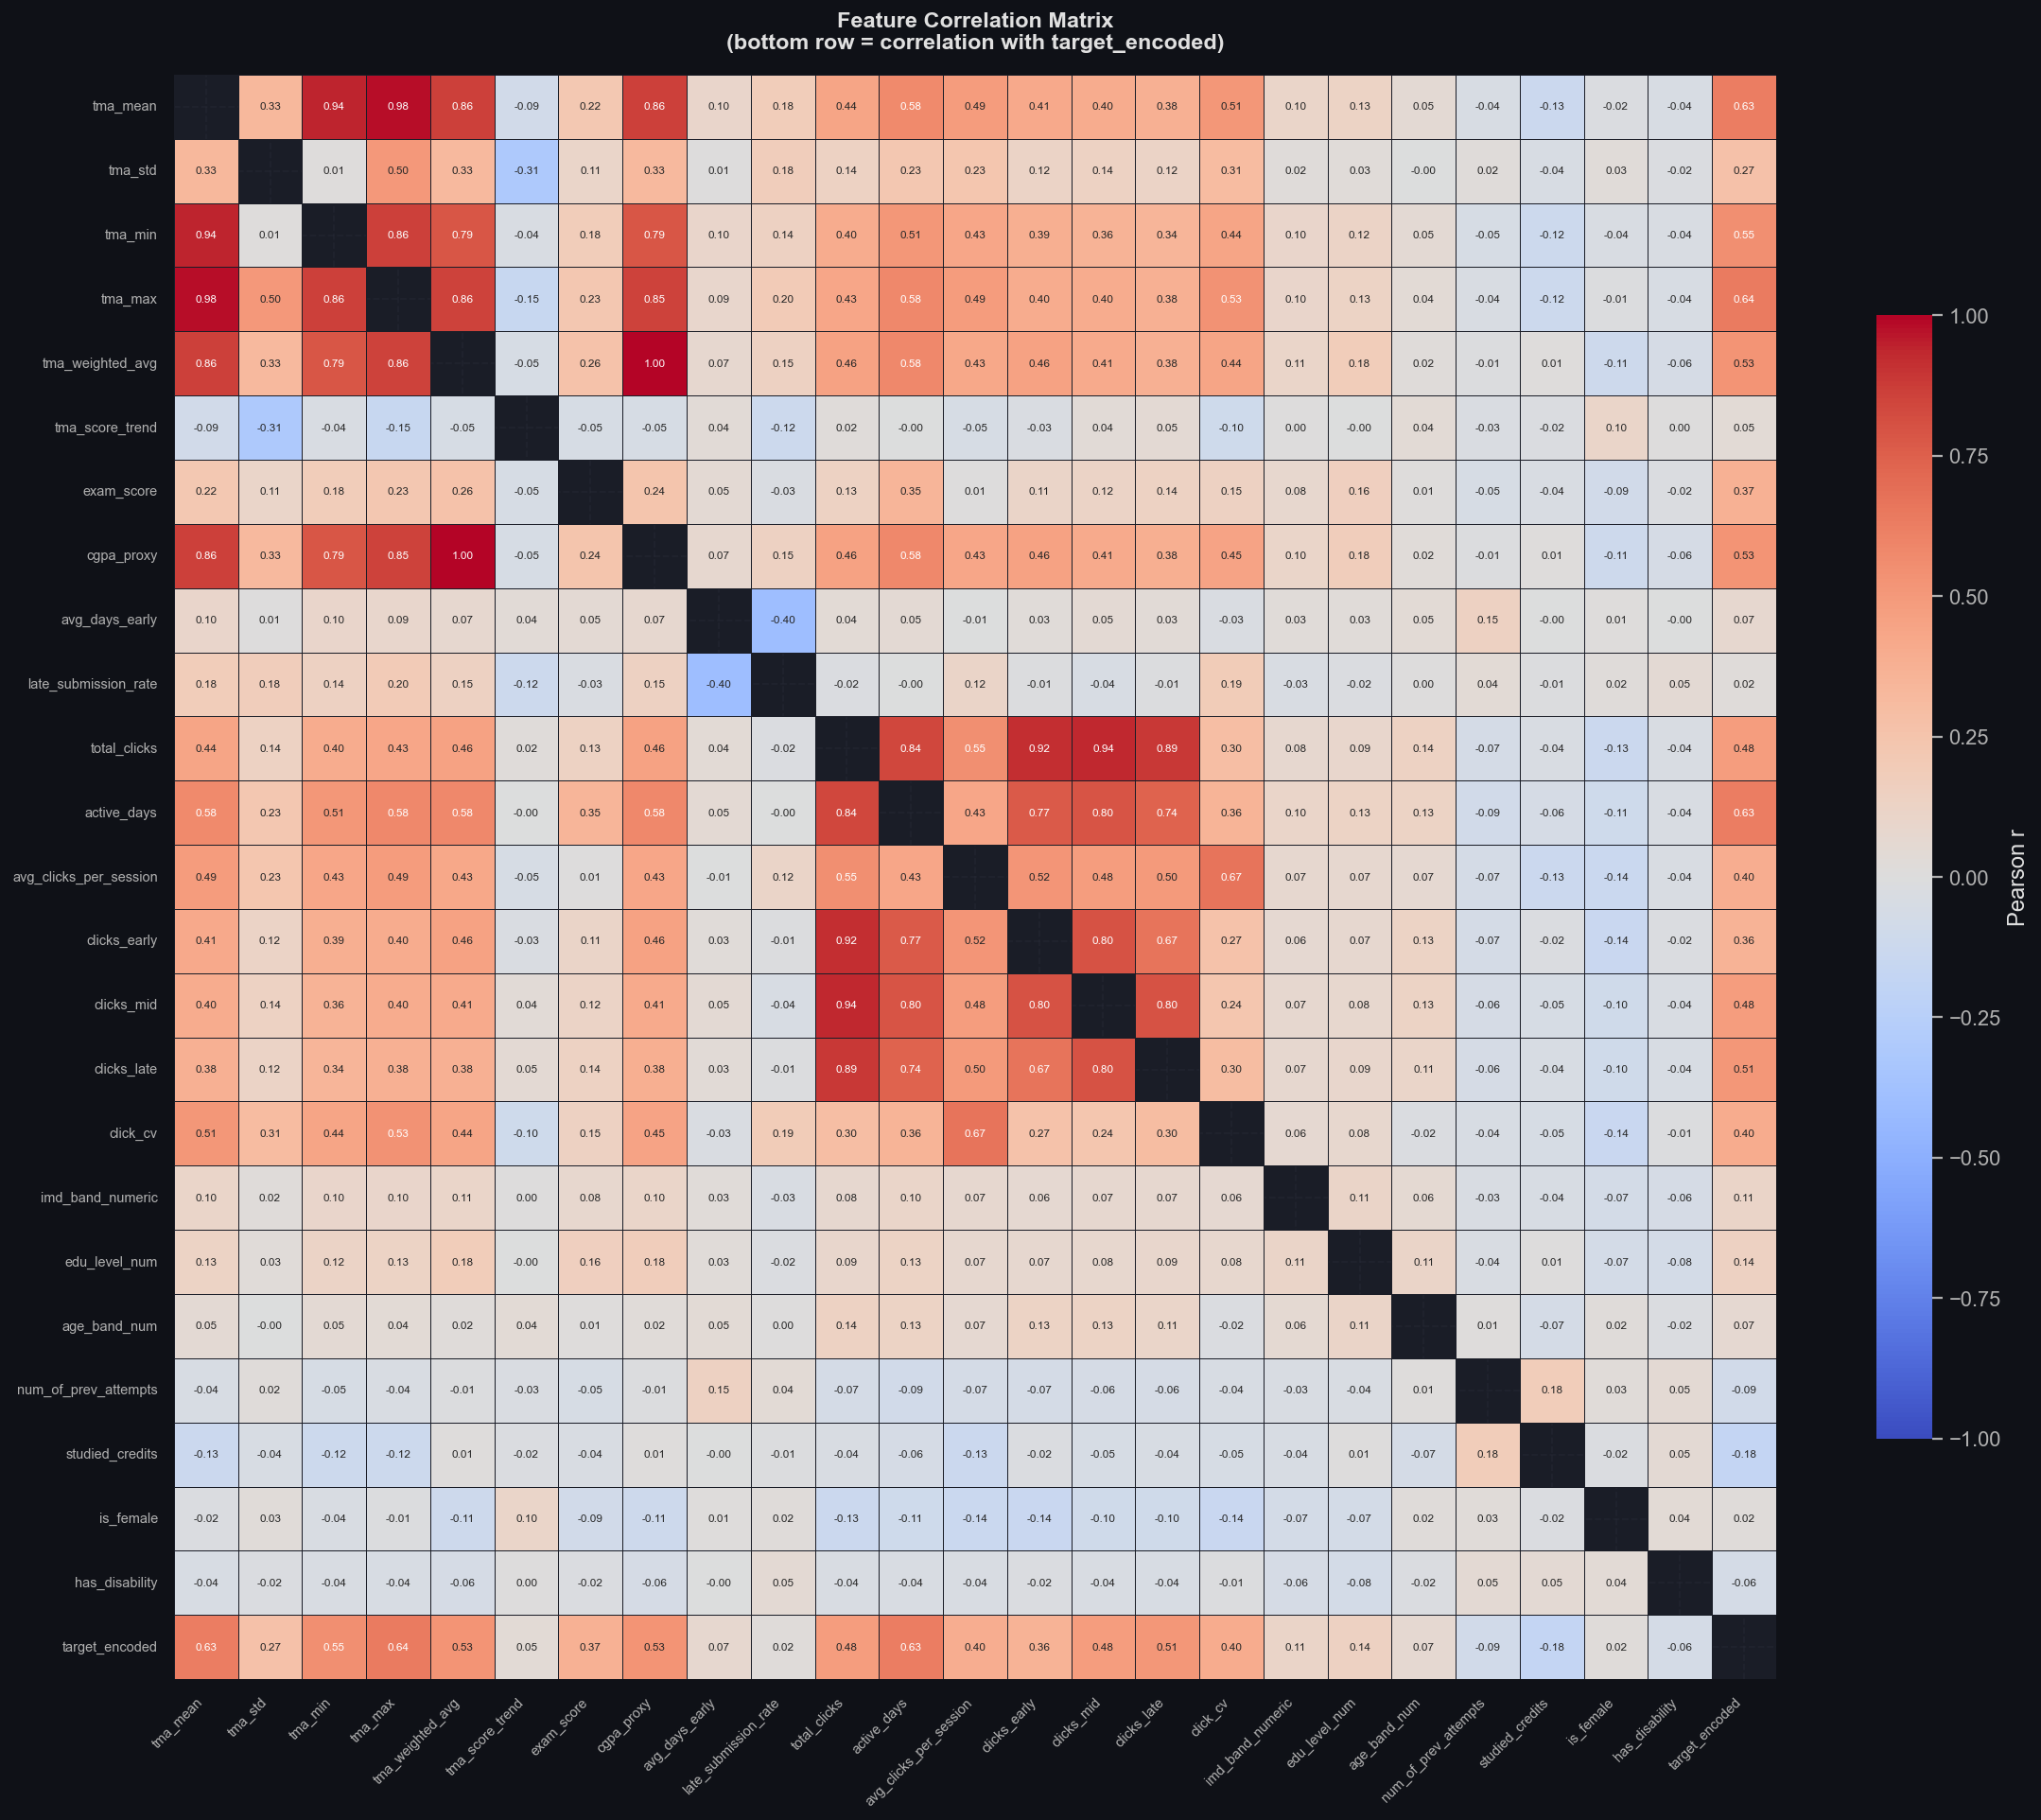

In [41]:
# Correlation Heatmap
num_features = [
    "tma_mean",
    "tma_std",
    "tma_min",
    "tma_max",
    "tma_weighted_avg",
    "tma_score_trend",
    "exam_score",
    "cgpa_proxy",
    "avg_days_early",
    "late_submission_rate",
    "total_clicks",
    "active_days",
    "avg_clicks_per_session",
    "clicks_early",
    "clicks_mid",
    "clicks_late",
    "click_cv",
    "imd_band_numeric",
    "edu_level_num",
    "age_band_num",
    "num_of_prev_attempts",
    "studied_credits",
    "is_female",
    "has_disability",
    "target_encoded",
]
num_features = [f for f in num_features if f in feat_df.columns]
corr = feat_df[num_features].corr()

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.zeros_like(corr, dtype=bool)
np.fill_diagonal(mask, True)  # hide diagonal only; show full matrix for research use

sns.heatmap(
    corr,
    ax=ax,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6.5},
    linewidths=0.3,
    linecolor="#1a1d27",
    cbar_kws={"shrink": 0.7, "label": "Pearson r"},
)
ax.set_title(
    "Feature Correlation Matrix\n(bottom row = correlation with target_encoded)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("6. correlation_heatmap.png")
plt.show()

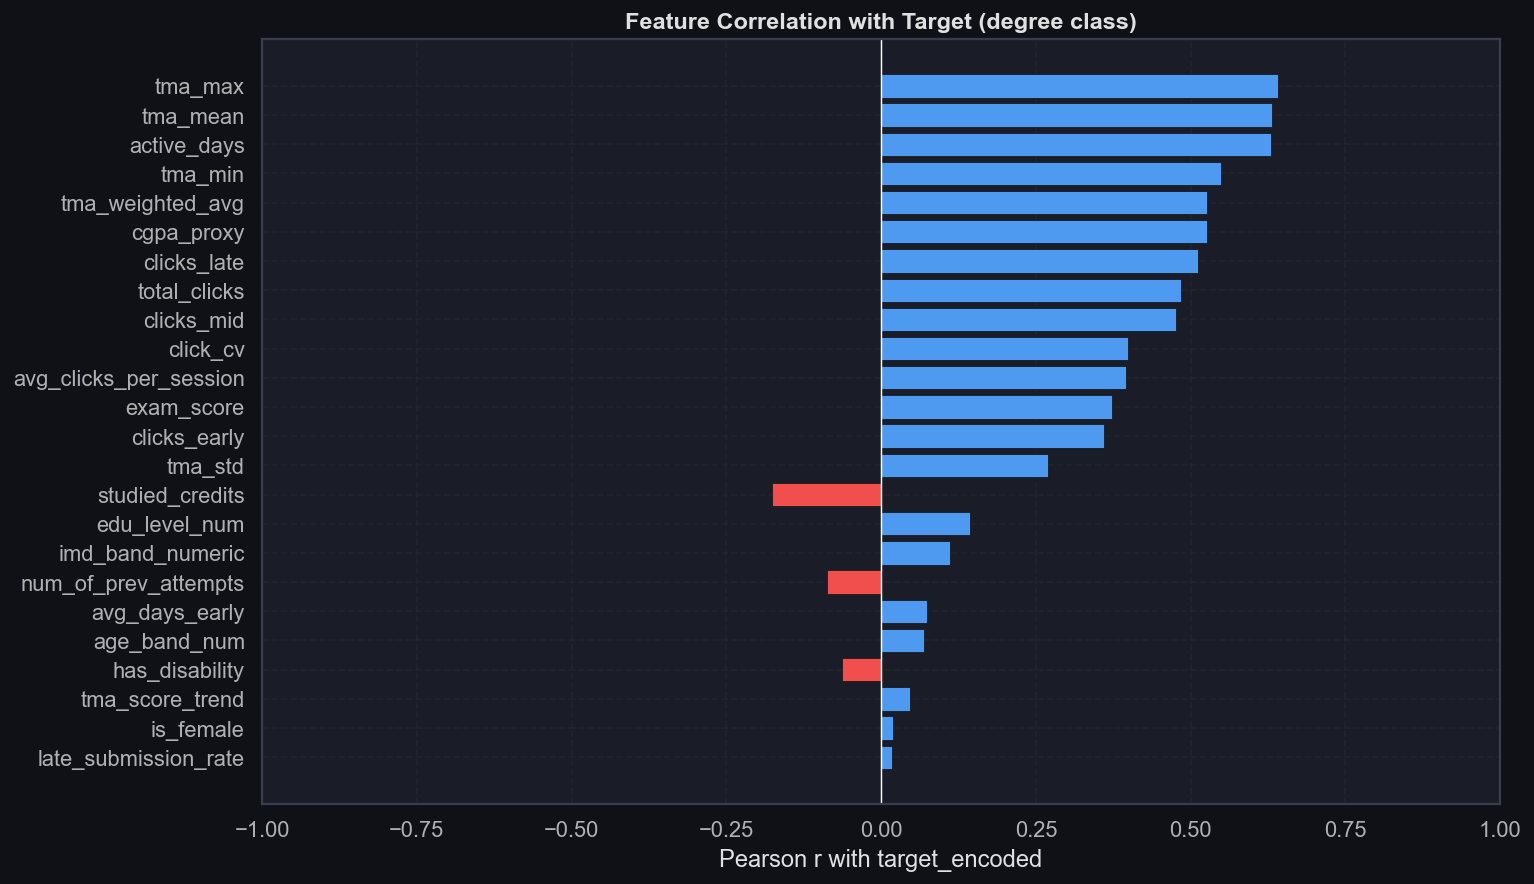

In [42]:
# Feature–Target Correlations (bar chart)
target_corr = (
    corr["target_encoded"].drop("target_encoded").sort_values(key=abs, ascending=False)
)
fig, ax = plt.subplots(figsize=(12, 7))
colors = ["#4e9af1" if v >= 0 else "#f14e4e" for v in target_corr.values]
ax.barh(
    target_corr.index[::-1],
    target_corr.values[::-1],
    color=colors[::-1],
    edgecolor="#111",
    linewidth=0.4,
)
ax.axvline(0, color="white", lw=0.8)
ax.set_title(
    "Feature Correlation with Target (degree class)",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("Pearson r with target_encoded")
ax.set_xlim(-1, 1)
plt.tight_layout()
plt.savefig("7. feature_target_correlation.png")
plt.show()

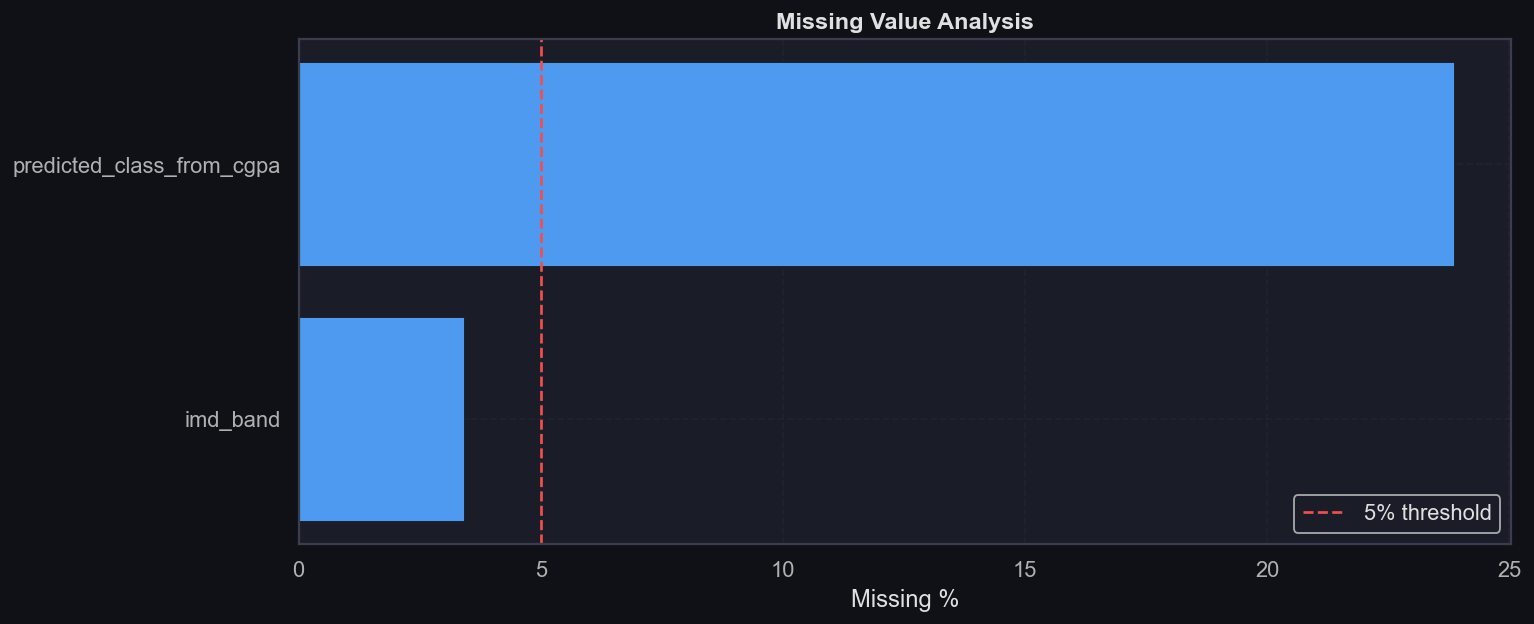

In [43]:
# Missing Values
miss = feat_df.isnull().mean().sort_values(ascending=False)
miss = miss[miss > 0]

fig, ax = plt.subplots(figsize=(12, 5))
if len(miss) > 0:
    ax.barh(
        miss.index[::-1],
        miss.values[::-1] * 100,
        color="#4e9af1",
        edgecolor="#111",
        linewidth=0.4,
    )
    ax.axvline(5, color="#f14e4e", lw=1.5, ls="--", label="5% threshold")
    ax.set_xlabel("Missing %")
    ax.legend()
else:
    ax.text(
        0.5,
        0.5,
        "✓  No missing values in the final feature matrix",
        ha="center",
        va="center",
        fontsize=14,
        transform=ax.transAxes,
        color="#4ef18a",
    )
ax.set_title("Missing Value Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("8. missing_values.png")
plt.show()

In [44]:
# ============================================================
# EXPORT MODEL-READY DATASET
# ============================================================

# ── Select only the features needed for modelling ───────────
model_features = [
    # Identifiers (kept for traceability, drop before training)
    "code_module",
    "code_presentation",
    "id_student",
    # Demographic / entry qualification
    "is_female",
    "has_disability",
    "age_band_num",
    "edu_level_num",
    "imd_band_numeric",
    "num_of_prev_attempts",
    "is_repeat_student",
    "studied_credits",
    # Assessment performance
    "tma_mean",
    "tma_std",
    "tma_min",
    "tma_max",
    "tma_weighted_avg",
    "tma_count",
    "tma_score_trend",
    "avg_days_early",
    "late_submission_rate",
    "exam_score",
    "cgpa_proxy",
    # VLE / engagement
    "total_clicks",
    "total_sessions",
    "avg_clicks_per_session",
    "active_days",
    "clicks_early",
    "clicks_mid",
    "clicks_late",
    "click_cv",
    # Target
    "target",
    "target_encoded",
]
model_features = [c for c in model_features if c in feat_df.columns]
model_df = feat_df[model_features].copy()

model_df.dropna(subset=["target"], inplace=True)

# Final numeric fill (catches any remaining NaN)
num_cols = model_df.select_dtypes(include=np.number).columns
model_df[num_cols] = model_df[num_cols].fillna(0)

model_df.to_csv("oulad_model_ready.csv", index=False)

print(f"\n  oulad_model_ready.csv saved")
print(f"  Shape            : {model_df.shape}")
print(
    f"  Features         : {len(model_features) - 3} predictors  (excl. identifiers + target)"
)
print(f"\n  Class distribution:")
for cls in TARGET_ORDER:
    n = (model_df["target"] == cls).sum()
    pct = n / len(model_df) * 100
    bar = "█" * int(pct / 2)
    print(f"    {cls:<14}  {n:>5}  ({pct:5.1f}%)  {bar}")

print(f"\n  Missing values   : {model_df.isnull().sum().sum()}")
print(f"\n  Feature list saved to: feature_list.txt")

with open("feature_list.txt", "w") as f:
    f.write("OULAD Model Feature List\n")
    f.write("=" * 40 + "\n\n")
    groups = {
        "Demographic / Entry Qualification": [
            "is_female",
            "has_disability",
            "age_band_num",
            "edu_level_num",
            "imd_band_numeric",
            "num_of_prev_attempts",
            "is_repeat_student",
            "studied_credits",
        ],
        "Assessment Performance": [
            "tma_mean",
            "tma_std",
            "tma_min",
            "tma_max",
            "tma_weighted_avg",
            "tma_count",
            "tma_score_trend",
            "avg_days_early",
            "late_submission_rate",
            "exam_score",
            "cgpa_proxy",
        ],
        "VLE / Engagement": [
            "total_clicks",
            "total_sessions",
            "avg_clicks_per_session",
            "active_days",
            "clicks_early",
            "clicks_mid",
            "clicks_late",
            "click_cv",
        ],
    }
    for group, feats in groups.items():
        f.write(f"\n{group}\n{'-'*len(group)}\n")
        for feat in feats:
            if feat in model_df.columns:
                f.write(f"  {feat}\n")



  oulad_model_ready.csv saved
  Shape            : (32593, 32)
  Features         : 29 predictors  (excl. identifiers + target)

  Class distribution:
    Distinction      3024  (  9.3%)  ████
    Pass            12361  ( 37.9%)  ██████████████████
    Fail             7052  ( 21.6%)  ██████████
    Withdrawn       10156  ( 31.2%)  ███████████████

  Missing values   : 0

  Feature list saved to: feature_list.txt



OULAD - Model Training Pipeline
Degree Class Prediction System  |  Objective ii
============================================================
Models trained:
  1. Logistic Regression       (baseline linear model)
  2. Support Vector Machine    (RBF kernel)
  3. Random Forest             (tree ensemble)
  4. Gradient Boosting (XGB-style via HistGradientBoosting)
  5. Voting Ensemble           (soft vote: LR + RF + HGB)
  6. Stacking Ensemble         (meta-learner: LR over RF + HGB + SVM)

Strategy:
  - SMOTE oversampling on training fold only (avoid data leakage)
  - Stratified 5-fold cross-validation
  - Class-weighted losses where supported
  - Separate pipelines for linear models (scaling + optional PCA)
    vs tree models (no scaling needed)
  - Hyperparameter tuning via RandomizedSearchCV
  - All results saved for Objective iii (evaluation)
============================================================

In [45]:
import time, joblib, json
from pathlib import Path

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV,
    train_test_split,
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_auc_score,
    make_scorer,
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

np.random.seed(42)

plt.rcParams.update(
    {
        "figure.facecolor": "#0f1117",
        "axes.facecolor": "#1a1d27",
        "axes.edgecolor": "#3a3d4d",
        "axes.labelcolor": "#e0e0e0",
        "xtick.color": "#b0b0b0",
        "ytick.color": "#b0b0b0",
        "text.color": "#e0e0e0",
        "grid.color": "#2a2d3a",
        "grid.linestyle": "--",
        "grid.alpha": 0.4,
        "figure.dpi": 130,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
        "savefig.facecolor": "#0f1117",
    }
)

TARGET_ORDER = ["Withdrawn", "Fail", "Pass", "Distinction"]
TARGET_COLORS = {
    "Distinction": "#4e9af1",
    "Pass": "#4ef18a",
    "Fail": "#f14e4e",
    "Withdrawn": "#f1c94e",
}
MODEL_COLORS = {
    "Logistic Regression": "#4e9af1",
    "SVM": "#c44ef1",
    "Random Forest": "#4ef18a",
    "Hist Gradient Boosting": "#f1c94e",
    "Voting Ensemble": "#f14e4e",
    "Stacking Ensemble": "#ff8c42",
}

OUTPUT_DIR = Path(".")

In [46]:
# Load the model-ready dataset
df = pd.read_csv("oulad_model_ready.csv")
print(f"  Loaded: {df.shape}")

  Loaded: (32593, 32)


In [47]:
# Drop non-feature columns
DROP_COLS = [
    "code_module",
    "code_presentation",
    "id_student",
    "target",  # string label (we use target_encoded)
    "predicted_class_from_cgpa",  # derived string column, ~24% missing
    "imd_band",  # raw string (already encoded as imd_band_numeric)
    "tma_count",  # low signal, dominated by withdrawn students
]
DROP_COLS = [c for c in DROP_COLS if c in df.columns]
df.drop(columns=DROP_COLS, inplace=True)

In [48]:
# Features & target
X = df.drop(columns=["target_encoded"])
y = df["target_encoded"]  # 0=Withdrawn, 1=Fail, 2=Pass, 3=Distinction

print(f"  Feature matrix : {X.shape}")
print(f"  Target classes : {dict(y.value_counts().sort_index())}")
print(f"  Class labels   : 0=Withdrawn  1=Fail  2=Pass  3=Distinction")

  Feature matrix : (32593, 26)
  Target classes : {0: 10156, 1: 7052, 2: 12361, 3: 3024}
  Class labels   : 0=Withdrawn  1=Fail  2=Pass  3=Distinction


In [49]:
#  Class weights (for weighted models) 
classes = np.array([0, 1, 2, 3])
class_names = ["Withdrawn", "Fail", "Pass", "Distinction"]
cw = compute_class_weight("balanced", classes=classes, y=y)
class_weight_dict = dict(zip(classes, cw))
print(f"\n  Balanced class weights: {class_weight_dict}")

#  Train / test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\n  Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"  Train class dist: {dict(y_train.value_counts().sort_index())}")
print(f"  Test  class dist: {dict(y_test.value_counts().sort_index())}")


  Balanced class weights: {0: 0.8023089799133517, 1: 1.1554523539421442, 2: 0.6591901949680447, 3: 2.6945271164021163}

  Train : (26074, 26)  |  Test : (6519, 26)
  Train class dist: {0: 8125, 1: 5641, 2: 9889, 3: 2419}
  Test  class dist: {0: 2031, 1: 1411, 2: 2472, 3: 605}


In [50]:
# 2. CROSS-VALIDATION SETUP
print("\n" + "=" * 60)
print("  STEP 2: CROSS-VALIDATION SETUP")
print("=" * 60)

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SMOTE_ = SMOTE(random_state=42, k_neighbors=5)

# Scorer: macro F1 (penalises ignoring minority classes equally)
SCORER = make_scorer(f1_score, average="macro")

CV_METRICS = {
    "accuracy": make_scorer(accuracy_score),
    "f1_macro": make_scorer(f1_score, average="macro"),
    "f1_weighted": make_scorer(f1_score, average="weighted"),
}

print("  Strategy  : Stratified 5-Fold CV")
print("  Sampling  : SMOTE applied INSIDE each training fold (no leakage)")
print("  Tuning    : RandomizedSearchCV (50 iterations, 3-fold inner CV)")
print("  Scorer    : macro F1")


  STEP 2: CROSS-VALIDATION SETUP
  Strategy  : Stratified 5-Fold CV
  Sampling  : SMOTE applied INSIDE each training fold (no leakage)
  Tuning    : RandomizedSearchCV (50 iterations, 3-fold inner CV)
  Scorer    : macro F1


## MODEL DEFINITIONS & PIPELINES

In [53]:
import sklearn
print(sklearn.__version__)

1.8.0


In [54]:
import inspect
print(inspect.signature(LogisticRegression.__init__))

(self, penalty='deprecated', *, C=1.0, l1_ratio=0.0, dual=False, tol=0.0001, fit_intercept=True, intercept_scaling=1, class_weight=None, random_state=None, solver='lbfgs', max_iter=100, verbose=0, warm_start=False, n_jobs=None)


In [56]:
# Logistic Regression
# Pipeline: SMOTE → StandardScaler → LR
# Multicollinear features handled by L2 regularisation
lr_pipe = ImbPipeline(
    [
        ("smote", SMOTE(random_state=42)),
        ("scaler", StandardScaler()),
        (
            "clf",
            LogisticRegression(
                solver="lbfgs",
                max_iter=2000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

lr_param_grid = {
    "clf__C": [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    "clf__penalty": ["l2"],
}

In [57]:
# Support Vector Machine (RBF)
# Pipeline: SMOTE → StandardScaler → SVC
svm_pipe = ImbPipeline(
    [
        ("smote", SMOTE(random_state=42)),
        ("scaler", StandardScaler()),
        (
            "clf",
            SVC(
                kernel="rbf",
                class_weight="balanced",
                probability=True,  # needed for soft voting & ROC-AUC
                random_state=42,
            ),
        ),
    ]
)

svm_param_grid = {
    "clf__C": [0.1, 1.0, 5.0, 10.0, 50.0],
    "clf__gamma": ["scale", "auto", 0.01, 0.001],
}

In [58]:
# Random Forest
# No scaling needed; natively handles multicollinearity
rf_pipe = ImbPipeline(
    [
        ("smote", SMOTE(random_state=42)),
        (
            "clf",
            RandomForestClassifier(
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

rf_param_grid = {
    "clf__n_estimators": [200, 300, 500],
    "clf__max_depth": [None, 10, 20, 30],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2"],
}

In [76]:
# Histogram Gradient Boosting
# Sklearn's fast XGBoost-like implementation;
# natively handles missing values & class imbalance via weight
hgb_pipe = ImbPipeline(
    [
        ("smote", SMOTE(random_state=42)),
        (
            "clf",
            HistGradientBoostingClassifier(
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

hgb_param_grid = {
    "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "clf__max_iter": [200, 300, 500],
    "clf__max_depth": [3, 5, 7, None],
    "clf__min_samples_leaf": [10, 20, 30],
    "clf__l2_regularization": [0.0, 0.1, 1.0],
}

print("  Defined 4 base model pipelines (LR, SVM, RF, HGB)")

  Defined 4 base model pipelines (LR, SVM, RF, HGB)


## HYPERPARAMETER TUNING

In [ ]:
tuned_models = {}
tune_configs = [
    ("Logistic Regression", lr_pipe, lr_param_grid, 30),
    ("SVM", svm_pipe, svm_param_grid, 20),
    ("Random Forest", rf_pipe, rf_param_grid, 40),
    ("Hist Gradient Boosting", hgb_pipe, hgb_param_grid, 40),
]

for name, pipe, param_grid, n_iter in tune_configs:
    print(f"  Tuning: {name} …", end=" ", flush=True)
    t0 = time.time()

    search = RandomizedSearchCV(
        pipe,
        param_grid,
        n_iter=n_iter,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        scoring="f1_macro",
        n_jobs=-1,
        random_state=42,
        refit=True,
        verbose=0,
    )
    search.fit(X_train, y_train)
    elapsed = time.time() - t0

    tuned_models[name] = search.best_estimator_
    print(f"done in {elapsed:.1f}s  |  best CV macro-F1 = {search.best_score_:.4f} | ")
    print(f"    Best params: {search.best_params_}")

  Tuning: Logistic Regression … done in 10.0s  |  best CV macro-F1 = 0.5934
    Best params: {'clf__penalty': 'l2', 'clf__C': 10.0}
  Tuning: SVM … done in 783.1s  |  best CV macro-F1 = 0.6618
    Best params: {'clf__gamma': 0.01, 'clf__C': 50.0}
  Tuning: Random Forest … done in 187.4s  |  best CV macro-F1 = 0.6951
    Best params: {'clf__n_estimators': 500, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 4, 'clf__max_features': 'sqrt', 'clf__max_depth': 20}
  Tuning: Hist Gradient Boosting … done in 76.7s  |  best CV macro-F1 = 0.6966
    Best params: {'clf__min_samples_leaf': 20, 'clf__max_iter': 500, 'clf__max_depth': 5, 'clf__learning_rate': 0.01, 'clf__l2_regularization': 1.0}


## ENSEMBLE MODELS

In [61]:
# Soft Voting Ensemble (LR + RF + HGB)
# Uses predicted class probabilities; LR provides calibrated probs
print("  Building Voting Ensemble (LR + RF + HGB)…")
voting_clf = VotingClassifier(
    estimators=[
        ("lr", tuned_models["Logistic Regression"]),
        ("rf", tuned_models["Random Forest"]),
        ("hgb", tuned_models["Hist Gradient Boosting"]),
    ],
    voting="soft",
    n_jobs=-1,
)
voting_clf.fit(X_train, y_train)
tuned_models["Voting Ensemble"] = voting_clf
print("  Voting Ensemble fitted.")

  Building Voting Ensemble (LR + RF + HGB)…
  Voting Ensemble fitted.


In [62]:
# Stacking Ensemble 
# Base learners: RF + HGB + SVM
# Meta-learner : Logistic Regression (learns how to combine predictions)
# Use cross_val_predict internally to avoid leakage on meta-features
print("  Building Stacking Ensemble (RF + HGB + SVM → LR)…")
stacking_clf = StackingClassifier(
    estimators=[
        ("rf", tuned_models["Random Forest"]),
        ("hgb", tuned_models["Hist Gradient Boosting"]),
        ("svm", tuned_models["SVM"]),
    ],
    final_estimator=LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        C=1.0,
        random_state=42,
    ),
    cv=5,
    stack_method="predict_proba",
    n_jobs=-1,
    passthrough=False,
)
stacking_clf.fit(X_train, y_train)
tuned_models["Stacking Ensemble"] = stacking_clf
print("  Stacking Ensemble fitted.")

  Building Stacking Ensemble (RF + HGB + SVM → LR)…
  Stacking Ensemble fitted.


## CROSS-VALIDATION EVALUATION (on training set)


In [63]:
cv_results = {}

for name, model in tuned_models.items():
    print(f"  CV: {name} …", end=" ", flush=True)
    t0 = time.time()

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=CV,
        scoring=CV_METRICS,
        n_jobs=-1,
        return_train_score=False,
    )
    elapsed = time.time() - t0

    cv_results[name] = {
        "accuracy_mean": scores["test_accuracy"].mean(),
        "accuracy_std": scores["test_accuracy"].std(),
        "f1_macro_mean": scores["test_f1_macro"].mean(),
        "f1_macro_std": scores["test_f1_macro"].std(),
        "f1_weighted_mean": scores["test_f1_weighted"].mean(),
        "f1_weighted_std": scores["test_f1_weighted"].std(),
    }

    print(
        f"done in {elapsed:.1f}s  |  "
        f"Acc={cv_results[name]['accuracy_mean']:.4f}±{cv_results[name]['accuracy_std']:.4f}  "
        f"F1-macro={cv_results[name]['f1_macro_mean']:.4f}±{cv_results[name]['f1_macro_std']:.4f}"
    )

cv_df = pd.DataFrame(cv_results).T.round(4)
print(f"\n  CV Summary:\n{cv_df.to_string()}")


  CV: Logistic Regression … done in 2.7s  |  Acc=0.6317±0.0083  F1-macro=0.5939±0.0088
  CV: SVM … done in 104.1s  |  Acc=0.6980±0.0058  F1-macro=0.6631±0.0052
  CV: Random Forest … done in 18.0s  |  Acc=0.7275±0.0043  F1-macro=0.6928±0.0043
  CV: Hist Gradient Boosting … done in 11.3s  |  Acc=0.7370±0.0042  F1-macro=0.6958±0.0045
  CV: Voting Ensemble … done in 32.3s  |  Acc=0.7318±0.0053  F1-macro=0.6942±0.0065
  CV: Stacking Ensemble … done in 463.5s  |  Acc=0.7460±0.0060  F1-macro=0.6922±0.0072

  CV Summary:
                        accuracy_mean  accuracy_std  f1_macro_mean  f1_macro_std  f1_weighted_mean  f1_weighted_std
Logistic Regression            0.6317        0.0083         0.5939        0.0088            0.6379           0.0081
SVM                            0.6980        0.0058         0.6631        0.0052            0.7011           0.0048
Random Forest                  0.7275        0.0043         0.6928        0.0043            0.7273           0.0041
Hist Gradient Boo

## HOLD-OUT TEST SET EVALUATION

In [64]:
test_results = {}
all_y_pred = {}
all_y_proba = {}

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_mac = f1_score(y_test, y_pred, average="macro")
    f1_wt = f1_score(y_test, y_pred, average="weighted")

    # OvR ROC-AUC (macro)
    try:
        auc = roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro")
    except Exception:
        auc = np.nan

    # Per-class F1
    report = classification_report(
        y_test, y_pred, target_names=class_names, output_dict=True, zero_division=0
    )

    test_results[name] = {
        "accuracy": round(acc, 4),
        "f1_macro": round(f1_mac, 4),
        "f1_weighted": round(f1_wt, 4),
        "roc_auc_macro": round(auc, 4) if not np.isnan(auc) else "N/A",
        "f1_Withdrawn": round(report["Withdrawn"]["f1-score"], 4),
        "f1_Fail": round(report["Fail"]["f1-score"], 4),
        "f1_Pass": round(report["Pass"]["f1-score"], 4),
        "f1_Distinction": round(report["Distinction"]["f1-score"], 4),
    }

    all_y_pred[name] = y_pred
    all_y_proba[name] = y_prob

    print(f"\n  ── {name} ──")
    print(f"     Accuracy     : {acc:.4f}")
    print(f"     F1 (macro)   : {f1_mac:.4f}")
    print(f"     F1 (weighted): {f1_wt:.4f}")
    print(
        f"     ROC-AUC OvR  : {auc:.4f}"
        if not np.isnan(auc)
        else "     ROC-AUC OvR  : N/A"
    )
    print(
        f"     Per-class F1 → Withdrawn:{report['Withdrawn']['f1-score']:.3f}  "
        f"Fail:{report['Fail']['f1-score']:.3f}  "
        f"Pass:{report['Pass']['f1-score']:.3f}  "
        f"Distinction:{report['Distinction']['f1-score']:.3f}"
    )

test_df = pd.DataFrame(test_results).T
print(f"\n  Test Set Summary:\n{test_df.to_string()}")


  ── Logistic Regression ──
     Accuracy     : 0.6487
     F1 (macro)   : 0.6123
     F1 (weighted): 0.6552
     ROC-AUC OvR  : 0.8851
     Per-class F1 → Withdrawn:0.767  Fail:0.475  Pass:0.703  Distinction:0.504

  ── SVM ──
     Accuracy     : 0.7024
     F1 (macro)   : 0.6666
     F1 (weighted): 0.7045
     ROC-AUC OvR  : 0.9095
     Per-class F1 → Withdrawn:0.766  Fail:0.514  Pass:0.789  Distinction:0.597

  ── Random Forest ──
     Accuracy     : 0.7355
     F1 (macro)   : 0.7026
     F1 (weighted): 0.7347
     ROC-AUC OvR  : 0.9248
     Per-class F1 → Withdrawn:0.782  Fail:0.541  Pass:0.824  Distinction:0.663

  ── Hist Gradient Boosting ──
     Accuracy     : 0.7397
     F1 (macro)   : 0.7019
     F1 (weighted): 0.7362
     ROC-AUC OvR  : 0.9255
     Per-class F1 → Withdrawn:0.783  Fail:0.531  Pass:0.834  Distinction:0.660

  ── Voting Ensemble ──
     Accuracy     : 0.7401
     F1 (macro)   : 0.7053
     F1 (weighted): 0.7389
     ROC-AUC OvR  : 0.9252
     Per-class F1 → Wi

## VISUALISATIONS

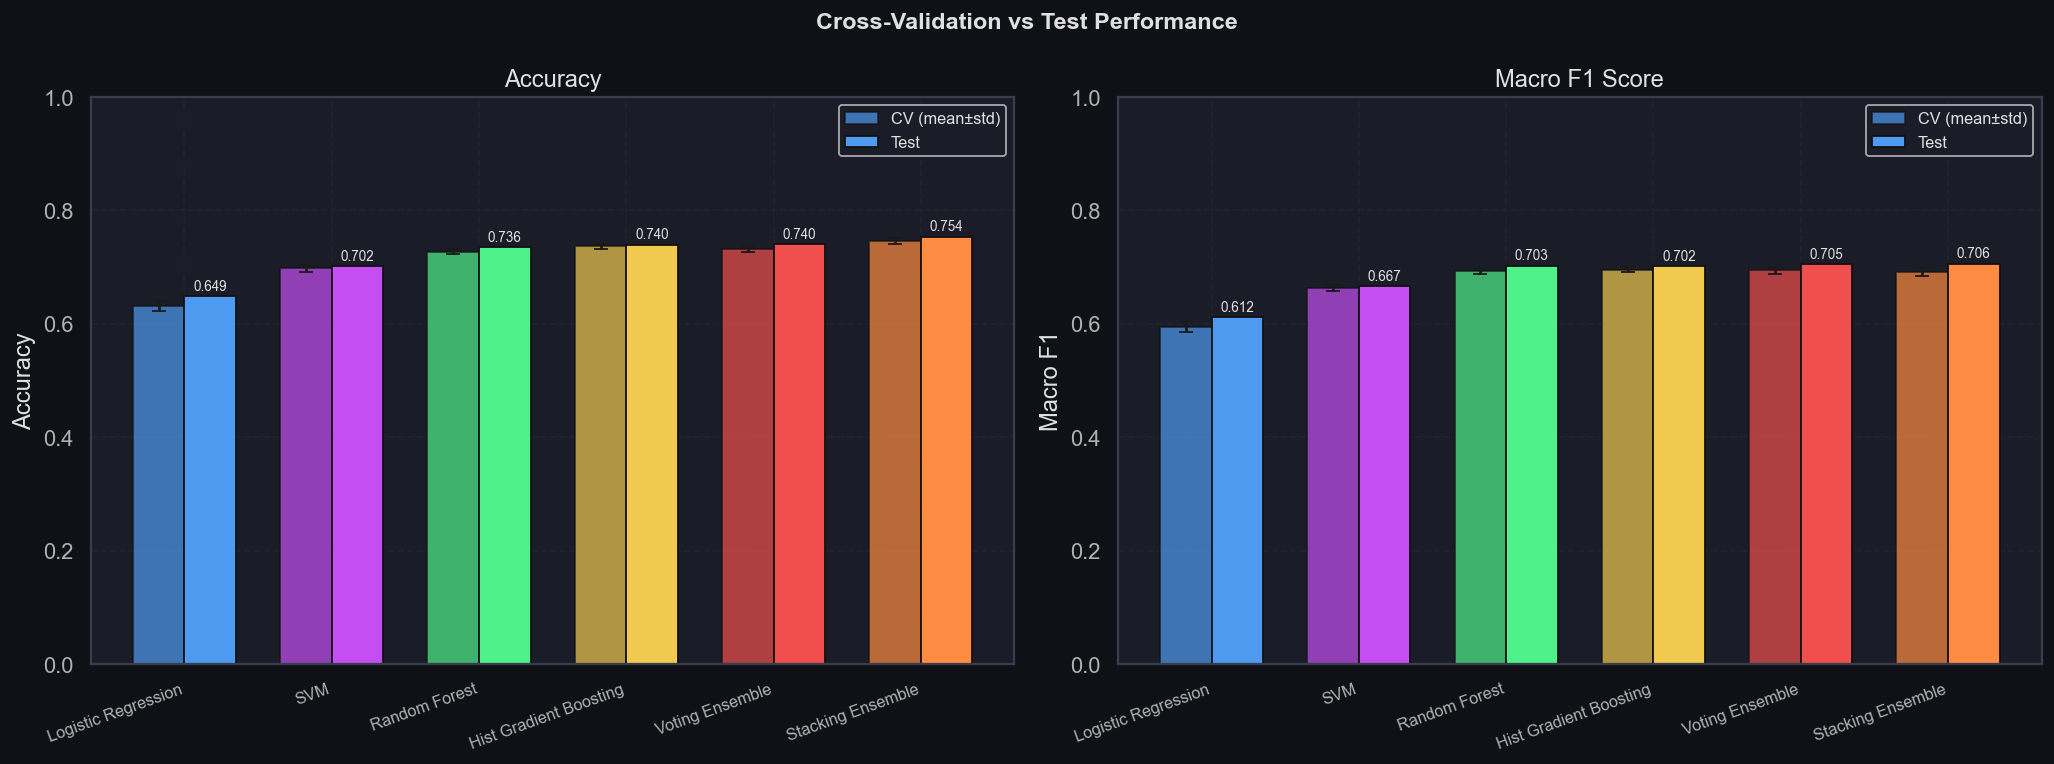

In [65]:
model_names = list(tuned_models.keys())
colors_list = [MODEL_COLORS.get(n, "#aaa") for n in model_names]

#  CV vs Test accuracy comparison 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Cross-Validation vs Test Performance", fontsize=13, fontweight="bold"
)

# Accuracy
cv_acc = [cv_results[n]["accuracy_mean"] for n in model_names]
cv_acc_e = [cv_results[n]["accuracy_std"] for n in model_names]
ts_acc = [test_results[n]["accuracy"] for n in model_names]

x = np.arange(len(model_names))
w = 0.35
bars1 = axes[0].bar(
    x - w / 2,
    cv_acc,
    w,
    yerr=cv_acc_e,
    capsize=4,
    color=colors_list,
    alpha=0.7,
    edgecolor="#111",
    label="CV (mean±std)",
)
bars2 = axes[0].bar(
    x + w / 2, ts_acc, w, color=colors_list, alpha=1.0, edgecolor="#111", label="Test"
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=20, ha="right", fontsize=9)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy")
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=9)
for bar in bars2:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=7.5,
    )

# Macro F1
cv_f1 = [cv_results[n]["f1_macro_mean"] for n in model_names]
cv_f1_e = [cv_results[n]["f1_macro_std"] for n in model_names]
ts_f1 = [test_results[n]["f1_macro"] for n in model_names]

bars3 = axes[1].bar(
    x - w / 2,
    cv_f1,
    w,
    yerr=cv_f1_e,
    capsize=4,
    color=colors_list,
    alpha=0.7,
    edgecolor="#111",
    label="CV (mean±std)",
)
bars4 = axes[1].bar(
    x + w / 2, ts_f1, w, color=colors_list, alpha=1.0, edgecolor="#111", label="Test"
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=20, ha="right", fontsize=9)
axes[1].set_ylabel("Macro F1")
axes[1].set_title("Macro F1 Score")
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=9)
for bar in bars4:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=7.5,
    )

plt.tight_layout()
plt.savefig("9. cv_vs_test.png")
plt.show()

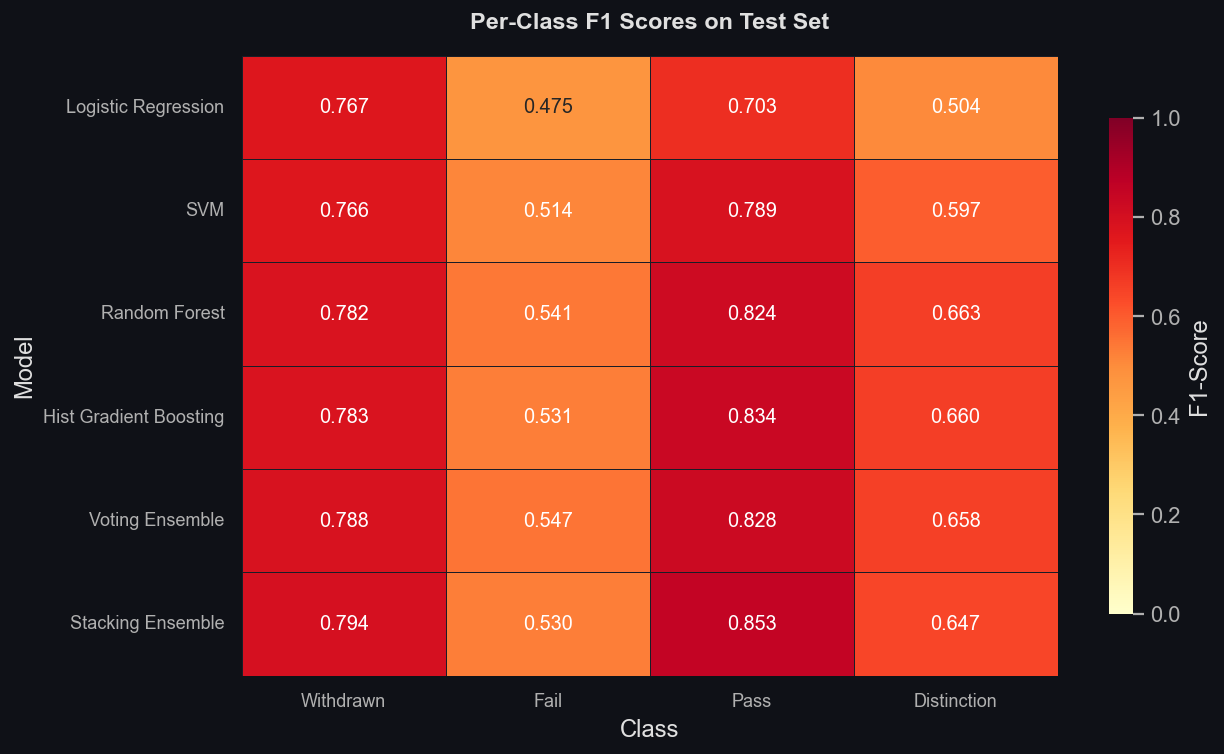

In [66]:
#  Per-class F1 heatmap 
per_class_data = {
    name: [test_results[name][f"f1_{c}"] for c in class_names] for name in model_names
}
per_class_df = pd.DataFrame(per_class_data, index=class_names).T

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    per_class_df,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor="#1a1d27",
    ax=ax,
    cbar_kws={"label": "F1-Score", "shrink": 0.8},
    annot_kws={"size": 11},
)
ax.set_title(
    "Per-Class F1 Scores on Test Set", fontsize=13, fontweight="bold", pad=15
)
ax.set_xlabel("Class")
ax.set_ylabel("Model")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.savefig("10. perclass_f1.png")
plt.show()

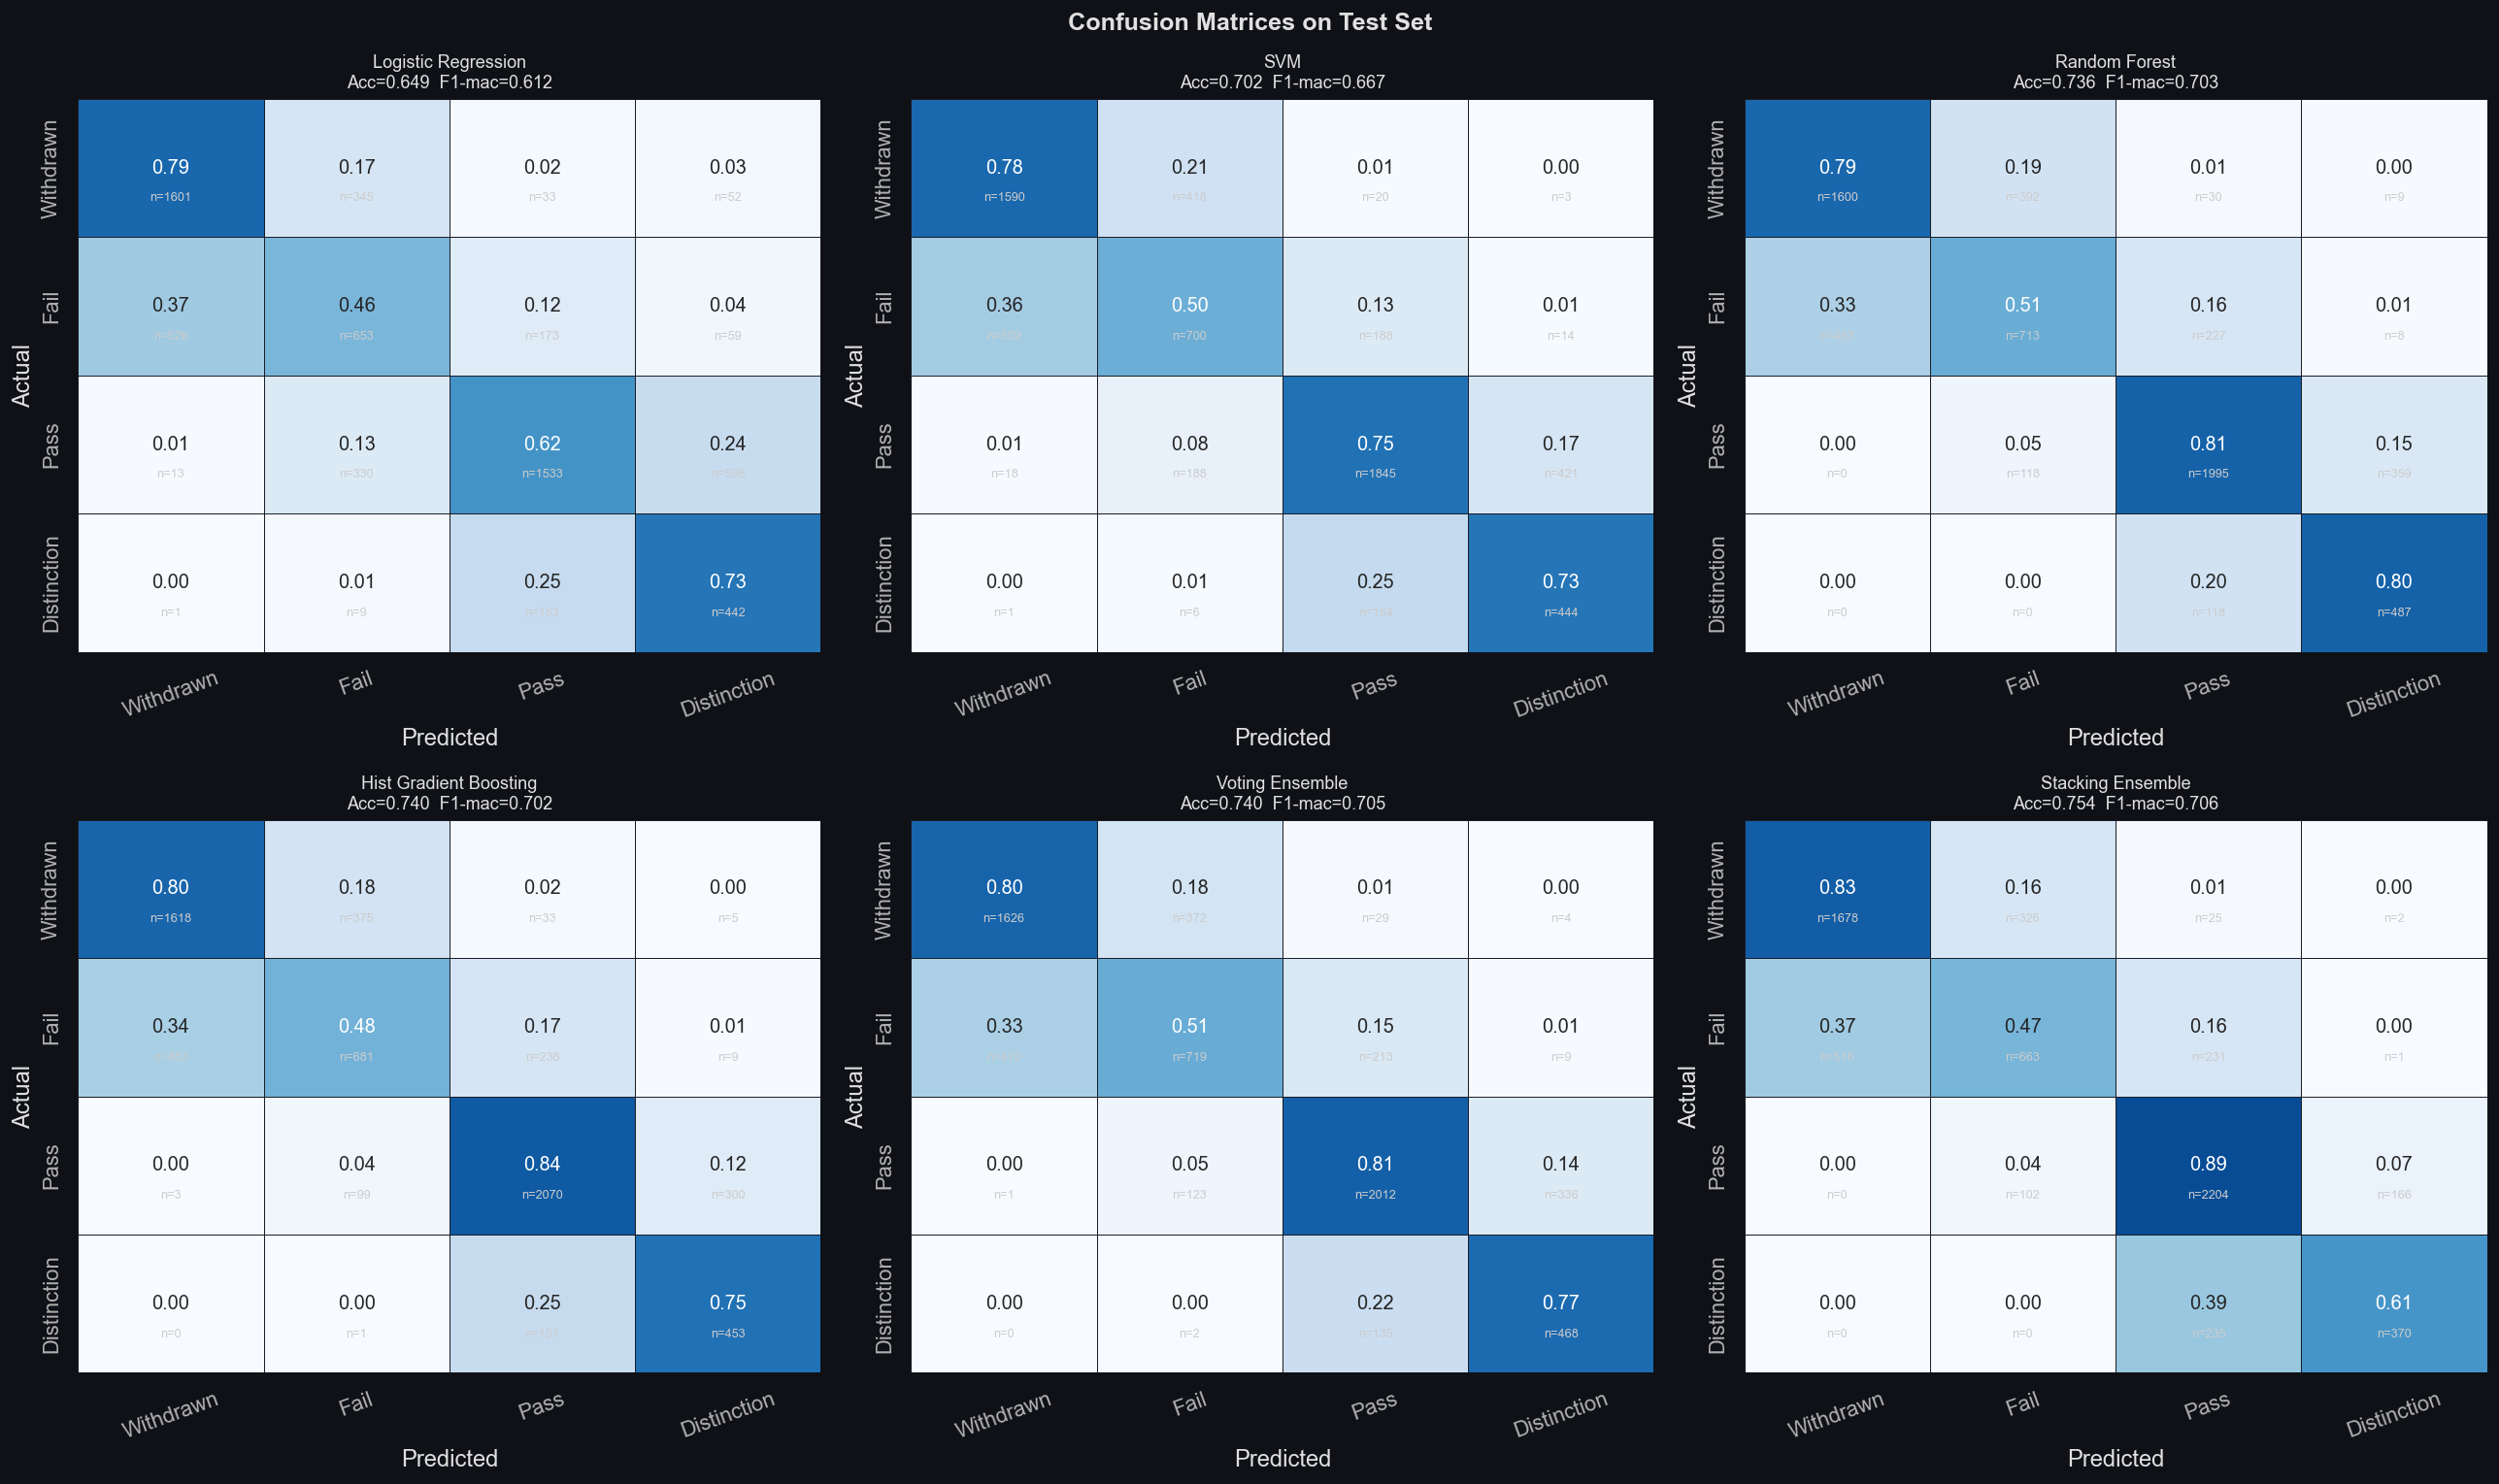

In [67]:
# Confusion matrices (2×3 grid) 
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(
    "Confusion Matrices on Test Set", fontsize=14, fontweight="bold"
)
axes = axes.flatten()

for i, (name, model) in enumerate(tuned_models.items()):
    if i >= 6:
        break
    cm = confusion_matrix(y_test, all_y_pred[name])
    # Normalise row-wise (recall per class)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues",
        ax=axes[i],
        vmin=0,
        vmax=1,
        linewidths=0.4,
        linecolor="#1a1d27",
        cbar=False,
        annot_kws={"size": 11},
    )

    # Overlay raw counts
    for row in range(len(class_names)):
        for col in range(len(class_names)):
            axes[i].text(
                col + 0.5,
                row + 0.72,
                f"n={cm[row,col]}",
                ha="center",
                va="center",
                fontsize=7,
                color="#ccc",
            )

    axes[i].set_title(
        f"{name}\nAcc={test_results[name]['accuracy']:.3f}  "
        f"F1-mac={test_results[name]['f1_macro']:.3f}",
        fontsize=10,
    )
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
    axes[i].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("11. confusion_matrices.png")
plt.show()

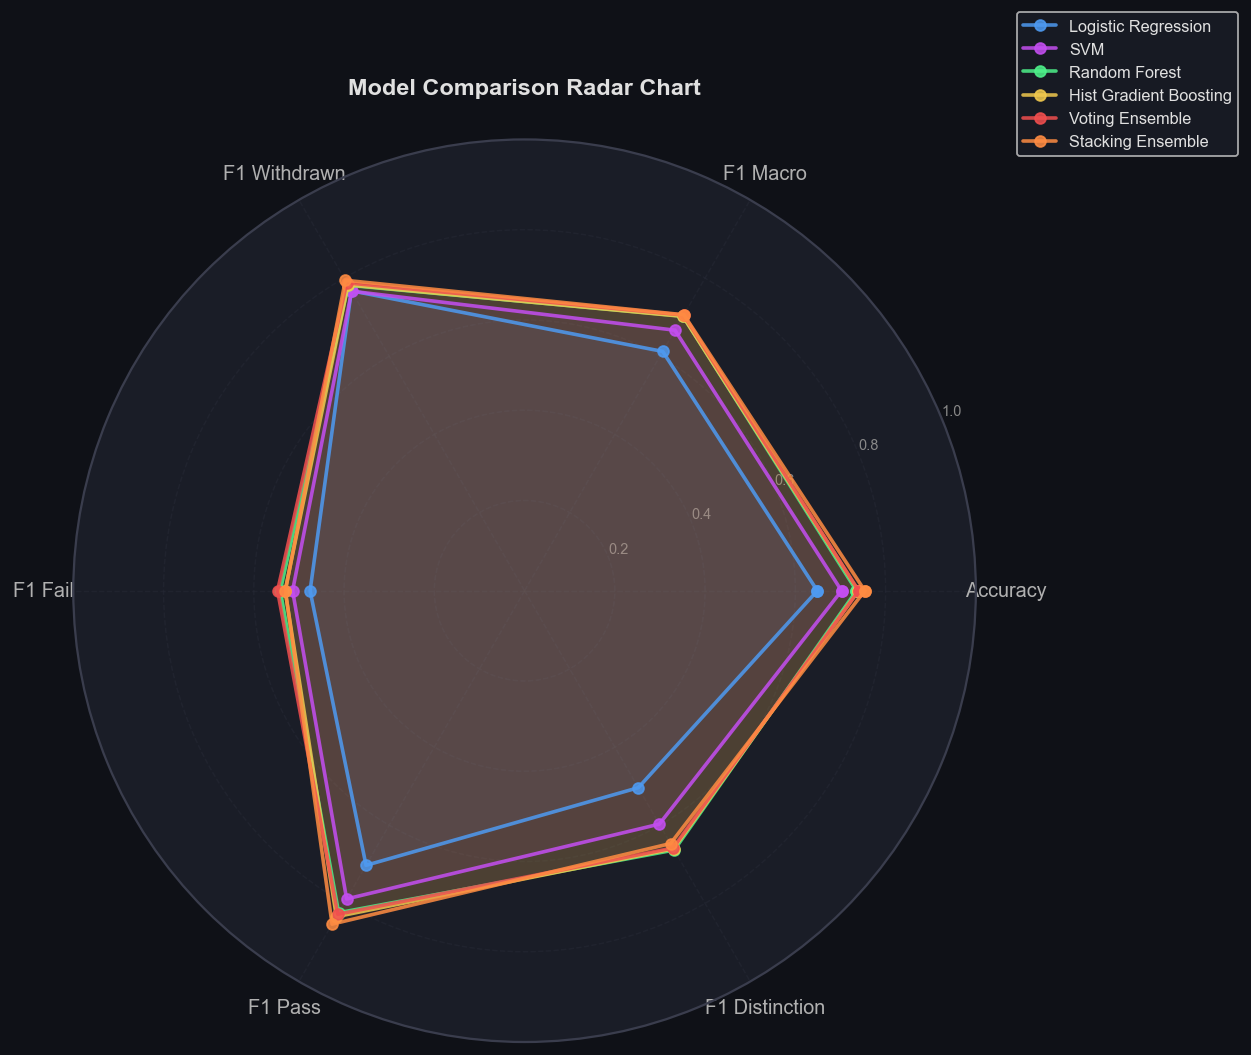

In [68]:
#  Radar chart — model comparison 
metrics_radar = [
    "accuracy",
    "f1_macro",
    "f1_Withdrawn",
    "f1_Fail",
    "f1_Pass",
    "f1_Distinction",
]
metric_labels = [
    "Accuracy",
    "F1 Macro",
    "F1 Withdrawn",
    "F1 Fail",
    "F1 Pass",
    "F1 Distinction",
]
N = len(metrics_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"polar": True})
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#1a1d27")

for name, color in MODEL_COLORS.items():
    if name not in test_results:
        continue
    values = [float(test_results[name].get(m, 0)) for m in metrics_radar]
    values += values[:1]
    ax.plot(angles, values, "o-", lw=2, color=color, label=name, alpha=0.85)
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_thetagrids(np.degrees(angles[:-1]), metric_labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=8, color="#888")
ax.grid(color="#2a2d3a", lw=0.8)
ax.spines["polar"].set_color("#3a3d4d")
ax.set_title(
    "Model Comparison Radar Chart",
    fontsize=13,
    fontweight="bold",
    pad=25,
    color="#e0e0e0",
)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig("12. radar.png")
plt.show()

  Computing permutation importance for Hist Gradient Boosting (this takes ~30s) … done.


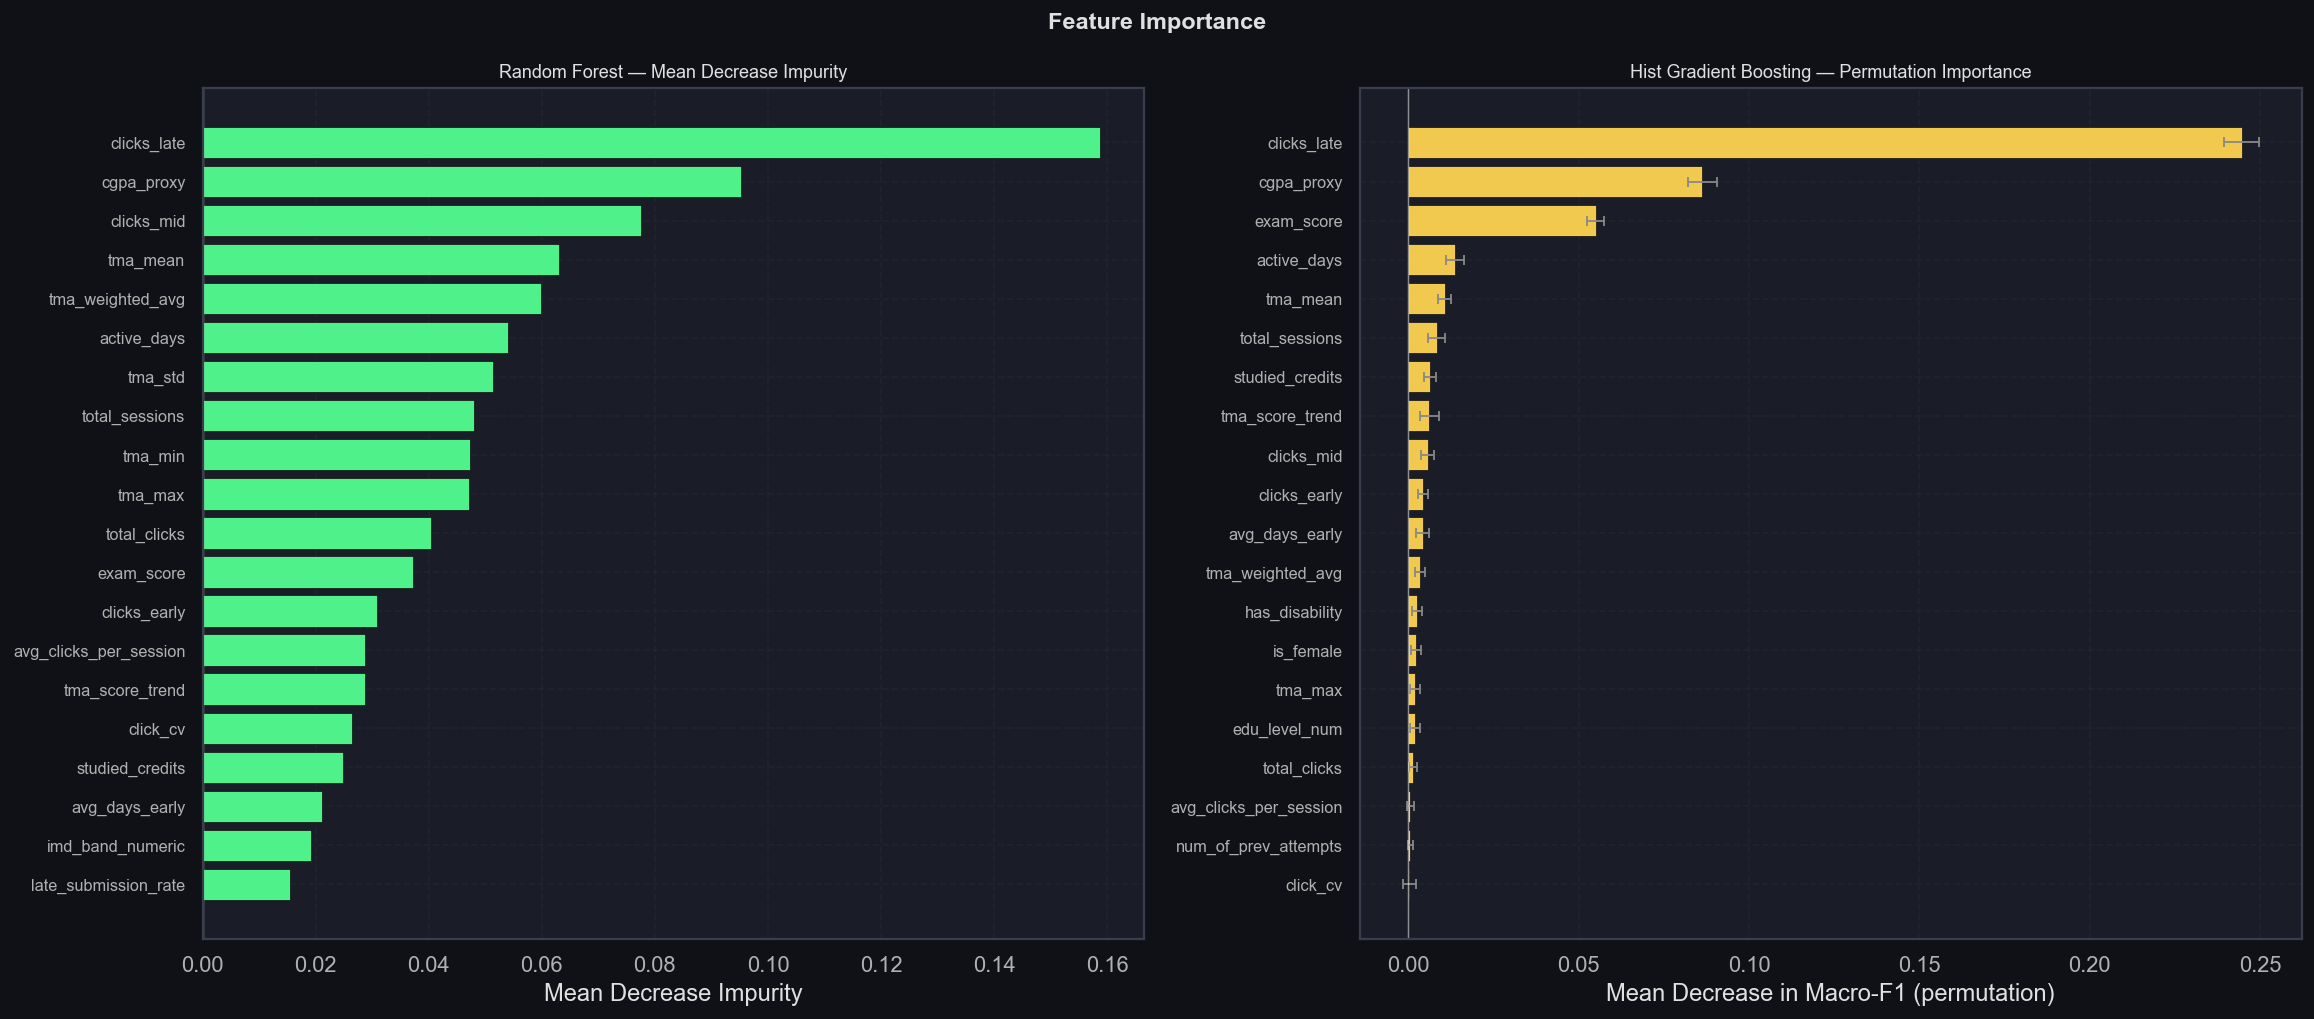

In [74]:
from sklearn.inspection import permutation_importance

# Feature importance (Random Forest & HGB)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Feature Importance", fontsize=13, fontweight="bold")

feature_names = X.columns.tolist()

for ax, model_key, title, method in [
    (axes[0], "Random Forest", "Random Forest — Mean Decrease Impurity", "native"),
    (
        axes[1],
        "Hist Gradient Boosting",
        "Hist Gradient Boosting — Permutation Importance",
        "permutation",
    ),
]:
    model = tuned_models[model_key]

    # Extract classifier step from the ImbPipeline
    clf = model.named_steps["clf"] if hasattr(model, "named_steps") else model

    if method == "native":
        # Random Forest has native feature_importances_
        importances = clf.feature_importances_
        errors = None
        xlabel = "Mean Decrease Impurity"

    else:
        # HGB in sklearn ≥1.4 no longer exposes feature_importances_
        # Use permutation importance on the test set instead
        # (more reliable anyway — measures actual predictive contribution)
        print(
            f"  Computing permutation importance for {model_key} "
            f"(this takes ~30s) …",
            end=" ",
            flush=True,
        )

        perm = permutation_importance(
            model,  # full pipeline (includes SMOTE-fitted scaler etc.)
            X_test,
            y_test,
            n_repeats=10,
            scoring="f1_macro",
            random_state=42,
            n_jobs=-1,
        )
        importances = perm.importances_mean
        errors = perm.importances_std
        xlabel = "Mean Decrease in Macro-F1 (permutation)"
        print("done.")

    # Top 20 features by importance
    indices = np.argsort(importances)[::-1][:20]
    top_feats = [feature_names[i] for i in indices[::-1]]
    top_vals = importances[indices[::-1]]
    top_errs = errors[indices[::-1]] if errors is not None else None

    ax.barh(
        top_feats,
        top_vals,
        xerr=top_errs,
        color=MODEL_COLORS[model_key],
        edgecolor="#111",
        linewidth=0.4,
        capsize=3,
        error_kw={"ecolor": "#888", "linewidth": 1},
    )
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.tick_params(axis="y", labelsize=9)
    ax.axvline(0, color="white", lw=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig("13.feature_importance.png")
plt.show()

In [75]:
# 9. SAVE MODELS & RESULTS
print("\n" + "=" * 60)
print("  STEP 9: SAVING MODELS & RESULTS")
print("=" * 60)

# Save all trained models
for name, model in tuned_models.items():
    fname = name.lower().replace(" ", "_") + "_model.pkl"
    joblib.dump(model, fname)
    print(f"  Saved: {fname}")

# Save results to CSV
cv_df.to_csv("cv_results.csv")
test_df.to_csv("test_results.csv")

# Save results as JSON (for the web app in Objective iv)
results_json = {
    "cv_results": cv_results,
    "test_results": test_results,
}
with open("model_results.json", "w") as f:
    json.dump(results_json, f, indent=2)
print("  Saved: cv_results.csv, test_results.csv, model_results.json")

# Save feature names (needed by the inference layer)
with open("feature_names.json", "w") as f:
    json.dump(feature_names, f)
print("  Saved: feature_names.json")

# Save label mapping
label_map = {"0": "Withdrawn", "1": "Fail", "2": "Pass", "3": "Distinction"}
with open("label_map.json", "w") as f:
    json.dump(label_map, f)
print("  Saved: label_map.json")


  STEP 9: SAVING MODELS & RESULTS
  Saved: logistic_regression_model.pkl
  Saved: svm_model.pkl
  Saved: random_forest_model.pkl
  Saved: hist_gradient_boosting_model.pkl
  Saved: voting_ensemble_model.pkl
  Saved: stacking_ensemble_model.pkl
  Saved: cv_results.csv, test_results.csv, model_results.json
  Saved: feature_names.json
  Saved: label_map.json


In [77]:

#  FINAL SUMMARY & BEST MODEL RECOMMENDATION


best_by_f1 = max(test_results, key=lambda n: test_results[n]["f1_macro"])
best_by_acc = max(test_results, key=lambda n: test_results[n]["accuracy"])
best_by_dist = max(test_results, key=lambda n: test_results[n]["f1_Distinction"])

print(f"\n  Best by Macro-F1      : {best_by_f1}")
print(f"  Best by Accuracy      : {best_by_acc}")
print(f"  Best by F1-Distinction: {best_by_dist}")

print("\n  Full leaderboard (sorted by macro F1):")
leaderboard = sorted(test_results.items(), key=lambda x: x[1]["f1_macro"], reverse=True)
print(f"  {'Model':<28}  {'Accuracy':>9}  {'F1-macro':>9}  {'F1-wt':>7}  {'AUC':>7}")
print("  " + "-" * 65)
for name, r in leaderboard:
    print(
        f"  {name:<28}  {r['accuracy']:>9.4f}  {r['f1_macro']:>9.4f}"
        f"  {r['f1_weighted']:>7.4f}  {str(r['roc_auc_macro']):>7}"
    )



  Best by Macro-F1      : Stacking Ensemble
  Best by Accuracy      : Stacking Ensemble
  Best by F1-Distinction: Random Forest

  Full leaderboard (sorted by macro F1):
  Model                          Accuracy   F1-macro    F1-wt      AUC
  -----------------------------------------------------------------
  Stacking Ensemble                0.7539     0.7061   0.7457   0.9271
  Voting Ensemble                  0.7401     0.7053   0.7389   0.9252
  Random Forest                    0.7355     0.7026   0.7347   0.9248
  Hist Gradient Boosting           0.7397     0.7019   0.7362   0.9255
  SVM                              0.7024     0.6666   0.7045   0.9095
  Logistic Regression              0.6487     0.6123   0.6552   0.8851


##  Retrain Stacking Ensemble on Top-20 RF Features

Run this ONCE in Jupyter before launching the Streamlit app.

Outputs saved to current directory:
  - top20_feature_names.json        ← feature list for app
  - stacking_top20_model.pkl        ← retrained model
  - top20_feature_importances.json  ← for app charts
  - label_map.json                  ← class decoder

In [78]:
# Load dataset

df = pd.read_csv("oulad_model_ready.csv")

DROP_COLS = [
    "code_module", "code_presentation", "id_student",
    "target", "predicted_class_from_cgpa", "imd_band", "tma_count",
]
DROP_COLS = [c for c in DROP_COLS if c in df.columns]
df.drop(columns=DROP_COLS, inplace=True)

X = df.drop(columns=["target_encoded"])
y = df["target_encoded"]

all_feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Load the previously trained Random Forest
rf_model = joblib.load("random_forest_model.pkl")
rf_clf   = rf_model.named_steps["clf"]

print(f"  Data shape      : {X.shape}")
print(f"  Train / Test    : {X_train.shape} / {X_test.shape}")
print(f"  RF loaded       : {rf_clf.__class__.__name__}")


  Data shape      : (32593, 26)
  Train / Test    : (26074, 26) / (6519, 26)
  RF loaded       : RandomForestClassifier


In [79]:
# EXTRACT TOP-20 FEATURES FROM RANDOM FOREST

importances  = rf_clf.feature_importances_
indices      = np.argsort(importances)[::-1]
top20_idx    = indices[:20]
top20_names  = [all_feature_names[i] for i in top20_idx]
top20_imp    = importances[top20_idx].tolist()

print(f"\n  {'Rank':<5} {'Feature':<30} {'Importance':>12}")
print("  " + "-" * 50)
for rank, (name, imp) in enumerate(zip(top20_names, top20_imp), 1):
    bar = "█" * int(imp * 300)
    print(f"  {rank:<5} {name:<30} {imp:>12.6f}  {bar}")

# Slice data to top-20 features only
X_train_20 = X_train[top20_names]
X_test_20  = X_test[top20_names]

print(f"\n  Reduced feature matrix: {X_train_20.shape}")


  Rank  Feature                          Importance
  --------------------------------------------------
  1     clicks_late                        0.158661  ███████████████████████████████████████████████
  2     cgpa_proxy                         0.095200  ████████████████████████████
  3     clicks_mid                         0.077466  ███████████████████████
  4     tma_mean                           0.063013  ██████████████████
  5     tma_weighted_avg                   0.059926  █████████████████
  6     active_days                        0.053978  ████████████████
  7     tma_std                            0.051377  ███████████████
  8     total_sessions                     0.048032  ██████████████
  9     tma_min                            0.047231  ██████████████
  10    tma_max                            0.047192  ██████████████
  11    total_clicks                       0.040367  ████████████
  12    exam_score                         0.037265  ███████████
  13    clicks_ea

In [80]:
# RETRAIN BASE MODELS ON TOP-20 FEATURES
# Load previously tuned hyperparameters from the saved models
# and rebuild each base learner pipeline with SMOTE + top-20 features


# Extract best hyperparams from saved tuned models 
def get_clf_params(pkl_name):
    """Load a saved model and extract its classifier's params."""
    m = joblib.load(pkl_name)
    clf = m.named_steps["clf"]
    return clf.get_params()


rf_params = get_clf_params("random_forest_model.pkl")
hgb_params = get_clf_params("hist_gradient_boosting_model.pkl")
svm_params = get_clf_params("svm_model.pkl")

print(f"  Loaded RF  params : {rf_params}")
print(f"  Loaded HGB params : {hgb_params}")
print(f"  Loaded SVM params : {svm_params}")

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Rebuild pipelines (SMOTE inside pipeline for CV safety) 
rf_pipe_20 = ImbPipeline(
    [
        ("smote", SMOTE(random_state=42)),
        ("clf", RandomForestClassifier(**rf_params)),
    ]
)

hgb_pipe_20 = ImbPipeline(
    [
        ("smote", SMOTE(random_state=42)),
        ("clf", HistGradientBoostingClassifier(**hgb_params)),
    ]
)

svm_pipe_20 = ImbPipeline(
    [
        ("smote", SMOTE(random_state=42)),
        ("scaler", StandardScaler()),
        ("clf", SVC(**svm_params)),
    ]
)

print("\n  Fitting base learners on top-20 features …")
import time

for name, pipe in [
    ("Random Forest", rf_pipe_20),
    ("HGB", hgb_pipe_20),
    ("SVM", svm_pipe_20),
]:
    t0 = time.time()
    pipe.fit(X_train_20, y_train)
    print(f"    {name:<18} fitted in {time.time()-t0:.1f}s")

  Loaded RF  params : {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 20, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 4, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 500, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
  Loaded HGB params : {'categorical_features': 'from_dtype', 'class_weight': 'balanced', 'early_stopping': 'auto', 'interaction_cst': None, 'l2_regularization': 1.0, 'learning_rate': 0.01, 'loss': 'log_loss', 'max_bins': 255, 'max_depth': 5, 'max_features': 1.0, 'max_iter': 500, 'max_leaf_nodes': 31, 'min_samples_leaf': 20, 'monotonic_cst': None, 'n_iter_no_change': 10, 'random_state': 42, 'scoring': 'loss', 'tol': 1e-07, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}
  Loaded SVM params : {'C': 50.0, 'break_ties': False, 'cache_size': 200,

In [82]:
# BUILD & FIT STACKING ENSEMBLE (TOP-20)

stacking_top20 = StackingClassifier(
    estimators=[
        ("rf", rf_pipe_20),
        ("hgb", hgb_pipe_20),
        ("svm", svm_pipe_20),
    ],
    final_estimator=LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        C=1.0,
        random_state=42,
    ),
    cv=5,
    stack_method="predict_proba",
    n_jobs=-1,
    passthrough=False,
)

print("  Fitting Stacking Ensemble (this takes a few minutes) …")
t0 = time.time()
stacking_top20.fit(X_train_20, y_train)
print(f"  Stacking Ensemble fitted in {time.time()-t0:.1f}s")

  Fitting Stacking Ensemble (this takes a few minutes) …
  Stacking Ensemble fitted in 200.1s


In [83]:
# EVALUATE TOP-20 MODEL vs FULL MODEL

class_names = ["Withdrawn", "Fail", "Pass", "Distinction"]

# Top-20 stacking
y_pred_20 = stacking_top20.predict(X_test_20)
y_prob_20 = stacking_top20.predict_proba(X_test_20)

acc_20 = accuracy_score(y_test, y_pred_20)
f1_20 = f1_score(y_test, y_pred_20, average="macro")
f1w_20 = f1_score(y_test, y_pred_20, average="weighted")
auc_20 = roc_auc_score(y_test, y_prob_20, multi_class="ovr", average="macro")

# Full stacking (for comparison)
full_stack = joblib.load("stacking_ensemble_model.pkl")
X_test_full = X_test[all_feature_names]
y_pred_full = full_stack.predict(X_test_full)
y_prob_full = full_stack.predict_proba(X_test_full)

acc_full = accuracy_score(y_test, y_pred_full)
f1_full = f1_score(y_test, y_pred_full, average="macro")
f1w_full = f1_score(y_test, y_pred_full, average="weighted")
auc_full = roc_auc_score(y_test, y_prob_full, multi_class="ovr", average="macro")

print(f"\n  {'Metric':<20} {'Full model (29 feats)':>22} {'Top-20 model':>14}")
print("  " + "-" * 58)
for metric, v_full, v_20 in [
    ("Accuracy", acc_full, acc_20),
    ("F1 Macro", f1_full, f1_20),
    ("F1 Weighted", f1w_full, f1w_20),
    ("ROC-AUC (OvR)", auc_full, auc_20),
]:
    diff = v_20 - v_full
    arrow = "▲" if diff >= 0 else "▼"
    print(f"  {metric:<20} {v_full:>22.4f} {v_20:>14.4f}  {arrow}{abs(diff):.4f}")

print(f"\n  Per-class F1 (Top-20 model):")
report = classification_report(
    y_test, y_pred_20, target_names=class_names, output_dict=True, zero_division=0
)
for cls in class_names:
    print(f"    {cls:<14}: {report[cls]['f1-score']:.4f}")


  Metric                Full model (29 feats)   Top-20 model
  ----------------------------------------------------------
  Accuracy                             0.7539         0.7533  ▼0.0006
  F1 Macro                             0.7061         0.7059  ▼0.0002
  F1 Weighted                          0.7457         0.7451  ▼0.0006
  ROC-AUC (OvR)                        0.9271         0.9270  ▼0.0000

  Per-class F1 (Top-20 model):
    Withdrawn     : 0.7931
    Fail          : 0.5260
    Pass          : 0.8540
    Distinction   : 0.6504


In [84]:
# SAVE ALL ARTIFACTS

# Retrained model
joblib.dump(stacking_top20, "stacking_top20_model.pkl")
print("  Saved: stacking_top20_model.pkl")

# Top-20 feature names (ordered by importance)
with open("top20_feature_names.json", "w") as f:
    json.dump(top20_names, f, indent=2)
print("  Saved: top20_feature_names.json")

# Feature importances (for app chart)
feat_imp_data = [
    {"feature": name, "importance": imp} for name, imp in zip(top20_names, top20_imp)
]
with open("top20_feature_importances.json", "w") as f:
    json.dump(feat_imp_data, f, indent=2)
print("  Saved: top20_feature_importances.json")

# Label map
label_map = {"0": "Withdrawn", "1": "Fail", "2": "Pass", "3": "Distinction"}
with open("label_map.json", "w") as f:
    json.dump(label_map, f, indent=2)
print("  Saved: label_map.json")

  Saved: stacking_top20_model.pkl
  Saved: top20_feature_names.json
  Saved: top20_feature_importances.json
  Saved: label_map.json


'1.26.0'